# Intro and Set Up #

In [1]:
import csv
import numpy as np
import pandas as pd
import torch 
import torch.nn as nn
from tqdm import tqdm
from scipy.stats import norm
import os

import matplotlib.pyplot as plt
import seaborn as sns

from tools.Parametric_Structure_Eval import StructureEval as SE

#Import min-max scaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Format the Parametric Training Data ##


In [2]:
def merge_data(file_path, file_root_list, save_name): 
    #This function merges multiple CSV files into a single DataFrame.
    random_error_idx = []
    for file_root_name in file_root_list:
        df = pd.read_csv(f"{file_path}/Random_Parametric_Designs_{file_root_name}_Updated.csv")
        if 'df_merged' in locals():
            df_merged = pd.concat([df_merged, df], ignore_index=True)
        else:
            df_merged = df
        
        # Load error indices if they exist
        try:
            error_idx = np.loadtxt(f"{file_path}/random_test_design_error_idx_{file_root_name}.csv", delimiter=',', dtype=int)
            try:
                len(error_idx)
            except:
                error_idx = np.array([error_idx])
            random_error_idx.extend(error_idx.tolist())
        except:
            print(f"No error indices found for {file_root_name}.")
    
    df_merged.to_csv(f"{file_path}/{save_name}_Parameters_All.csv", index=False)
    #Save the error indices to a CSV file
    if random_error_idx:
        print(random_error_idx)

        np.savetxt(f"{file_path}/random_test_design_error_idx_All.csv", random_error_idx, delimiter=',', fmt='%d')
    


# Read in the structural elements data
df_columns = np.array(['Steel_Volume [m^3]',
               'Steel_Weight [tons]',
               'Unit_Steel_Weight [tons/m^3]',
               'Steel_LCG [m]',
               'Steel_YCG [m]',
               'Steel_VCG [m]',
               'Cross_Sectional_Area [m^2]',
               'z_Centroid_CX [m]',
               'y_Centroid_CX [m]',
               'I_11 [m^4]',
               'I_22 [m^4]', 
               'Max_Bending_Moment [Nm]'
               ])
    

def format_training_data(file_path, file_root_name, num_samples):
    """
    Reads in the Structural_elements.csv file, evaluates the structural elements, and formats the data for training.
    
    Parameters:
    - file_path: Path to the directory containing the CSV files.
    - file_root_name: Root name of the CSV files to be processed.
    - num_samples: Number of samples to process.
    
    Returns:
    - df_formatted: DataFrame containing formatted training data.
    """
    data = np.zeros((num_samples, 12))
    constraint_thresholds = pd.DataFrame(index=np.arange(num_samples))
    constraint_evals = pd.DataFrame(index=np.arange(num_samples))
    error_idx = []
    try:
        error_idx = np.loadtxt(f"{file_path}/{file_root_name}_error_idx_ALL.csv", delimiter=',', dtype=int)
        len(error_idx)
        print(f"Error indices found: {error_idx}")
    except:
        print(f"No error indices found for {file_root_name}.")
        error_idx = []
    
    check_labels = True
    for i in tqdm(range(num_samples)):
        #Check if the index is in the error list
        
        if i in error_idx:
            print(f"Skipping index {i} due to previous error.")
            data[i, :] = np.nan
            continue
        try:
            df = pd.read_csv(f"{file_path}/{file_root_name}_{i}_Structural_elements.csv")
        except:
            print(f"Error reading file for index {i}. Skipping this sample.")
            data[i, :] = np.nan
            continue
        
        structE = SE(df)
        data[i, 0] = structE.Volume()
        data[i, 1:3] = structE.Structural_Weight()
        data[i, 3:6] = structE.Volume_Centroid()
        data[i, 6:12] = structE.Effective_Longitudinal_CrossSection_Properties()

        thresh, evals = structE.Calculate_Transverse_Struct_Constraints()
        if check_labels: 
            constraint_thresholds = pd.DataFrame(columns=thresh.keys(), index=np.arange(num_samples))
            constraint_evals = pd.DataFrame(columns=evals.keys(), index=np.arange(num_samples))
            spacings,dims = structE.Calculate_Spacings_and_Sizes()

            print(spacings)
            print(dims)
            check_labels = False
            
        constraint_thresholds.iloc[i] = thresh
        constraint_evals.iloc[i] = evals

        
    
    # Create a DataFrame with the formatted data
    #print(data)
    df_formatted = pd.DataFrame(data, columns=df_columns)
    

    # Save the formatted data to a CSV file
    df_formatted.to_csv(f"{file_path}/{file_root_name}_Structural_Properties.csv", index=False)
    # convert all nans to 0s in the constraint dataframes and save them
    constraint_thresholds = constraint_thresholds.fillna(0.0)
    constraint_evals = constraint_evals.fillna(0.0)


    # All spacing reqs are 'Maximum' so we multiply these by -1 to convert them to 'Minimum' for the constraint evaluation

    spacing_cons_names = np.array(['Bottom_Floor_Spacing',
                                   'Bottom_Frame_Spacing',
                                   'Frame_Spacing'
                                   ])
    for cons in spacing_cons_names:
        constraint_thresholds[cons] = -1.0*constraint_thresholds[cons]
        constraint_evals[cons] = -1.0*constraint_evals[cons]


    constraint_thresholds.to_csv(f"{file_path}/{file_root_name}_Constraint_Thresholds.csv", index=False)
    constraint_evals.to_csv(f"{file_path}/{file_root_name}_Constraint_Values.csv", index=False)
    




In [4]:
file_path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'
#file_root_name = 'parametric_test_design'
file_root_name = 'random_test_design'
num_samples = 5050

#merge_data(file_path, np.array(['0_999', '1000_1999', '2000_3999', '4000_5049']), file_root_name) #999', '4000_4999', '5000_5006']))

#format_training_data(file_path, file_root_name, num_samples)


    
   

In [5]:
## Side Function: Evaluate the structural elements/parameters and check if the hopper stiffeners interfere with the tranvsverse bulkhead stiffeners. This is a side function that is not used in the main training and optimization process, but can be used to check if the hopper stiffeners interfere with the transverse bulkhead stiffeners.


def check_hopper_bulkhead_interference(file_path, file_root_name, num_samples):
    """
    Reads in the Structural_elements.csv file, evaluates the structural elements, and formats the data for training.
    
    Parameters:
    - file_path: Path to the directory containing the CSV files.
    - file_root_name: Root name of the CSV files to be processed.
    - num_samples: Number of samples to process.
    
    Returns:
    Hopper_data. a dataframe that contains an evaluation on the hopper stiffeners and their interference with the transverse bulkhead stiffeners.
    """

    #Assign hopper_data to have length of num_samples and columns for the index, structure class, and the minimum distances between the hopper stiffeners and the transverse bulkhead stiffeners.
    hopper_data = pd.DataFrame(columns=['Index', 
                                        'Structure_Class', 
                                        'Min Y dist: Hop stiff. vs Vert. Blkhd Stiff', 
                                        'Min Z dist: Hop stiff. vs Horiz. Blkhd Stiff', 
                                        'Min Y dist: Lower Hop stiff. vs Long. Blkhd',  
                                        'bit_Hopper_Stiff_too_Close_50mm', 
                                        'bit_Hopper_Stiff_too_Close_100mm'])
    
    hopper_data = hopper_data.reindex(index=np.arange(num_samples))

  
    error_idx = np.loadtxt(f"{file_path}/{file_root_name}_error_idx_ALL.csv", delimiter=',', dtype=int)
    try:
        len(error_idx)
        print(f"Error indices found: {error_idx}")
    except:
        error_idx = [error_idx]
    
    check_labels = True

    for i in tqdm(range(num_samples)):
        #Check if the index is in the error list
        
        if i in error_idx:
            print(f"Skipping index {i} due to previous error.")
            continue

        df = pd.read_csv(f"{file_path}/{file_root_name}_{i}_Structural_elements.csv")
        structE = SE(df)

        # First check for existence of 'Hopper Pannel' in 'Class'
        if 'Hopper Pannel' in df['Class'].values:
            # Get Object ID of Hopper_Pannels
            hopper_ids = df[df['Class'] == 'Hopper Pannel']['Object_ID'].unique()
            # Get rot of first hopper pannel
            hopper_rot = df[df['Class'] == 'Hopper Pannel']['rot'].values[0]


            #Get Unique Y and Z positions of the hopper stiffeners - objects with Parent_Struct in hopper_ids. 
            Ys = df[df['Parent_Struct'].isin(hopper_ids)]['y_loc'].unique()
            Zs = df[df['Parent_Struct'].isin(hopper_ids)]['z_loc'].unique()

            #print(f"Index: {i}, Hopper Stiffener Y positions: {Ys}, Z positions: {Zs}")

            # Get vert bulkhead stiffeners - objects with Class 'Transverse_Bulkhead_Vertical_Stiffener'
            Y_blkhd_stiffs = df[df['Class'] == 'Transverse_Bulkhead_Vertical_Stiffener']['y_loc'].unique()
            # Get horiz bulkhead stiffeners - objects with Class 'Transverse_Bulkhead_Horizontal_Stiffener'
            Z_blkhd_stiffs = df[df['Class'] == 'Transverse_Bulkhead_Transverse_Stiffener']['z_loc'].unique()

            #print(f"Index: {i}, Vertical Bulkhead Stiffener Y positions: {Y_blkhd_stiffs}, Horizontal Bulkhead Stiffener Z positions: {Z_blkhd_stiffs}")

            # Calculate the abs difference between all the Ys and Y_blkhd_stiffs, and find the minimum distance that is not zero
            diffs = np.abs(Ys[:, None] - Y_blkhd_stiffs[None, :])
            diffs[diffs< 1e-10] = 1.0  # Ignore zero differences
            min_Y_dist = np.min(diffs)
            # Calculate the abs difference between all the Zs and Z_blkhd_stiffs, and find the minimum distance
            diffs_z = np.abs(Zs[:, None] - Z_blkhd_stiffs[None, :])
            diffs_z[diffs_z< 1e-10] = 1.0  # Ignore zero differences
            min_Z_dist = np.min(diffs_z)

            #Assign values to the hopper_data dataframe
            hopper_data.loc[i, 'Index'] = i
            if hopper_rot == 90:
                hopper_data.loc[i, 'Structure_Class'] = 'containership'
            else:
                hopper_data.loc[i, 'Structure_Class'] = 'bulkcarrier'
            
            hopper_data.loc[i, 'Min Y dist: Hop stiff. vs Vert. Blkhd Stiff'] = min_Y_dist
            hopper_data.loc[i, 'Min Z dist: Hop stiff. vs Horiz. Blkhd Stiff'] = min_Z_dist

            # Now check for longitudinal bulkhead and inner side shell interference with the lower hopper stiffeners.
            if 'Longitudinal_Bulkhead' in df['Class'].values:
                # Get Object ID of Longitudinal_Bulkhead
                long_blkhd_ids = df[df['Class'] == 'Longitudinal_Bulkhead']['Object_ID'].unique()
                # Get Y positions of the longitudinal bulkhead stiffeners - objects with Parent_Struct in long_blkhd_ids. 
                y_long_blkhd = df[df['Parent_Struct'].isin(long_blkhd_ids)]['y_loc'].unique()
                # Calculate the abs difference between all the Ys and y_long_blkhd, and find the minimum distance
                diffs_long_blkhd = np.abs(Ys[:, None] - y_long_blkhd[None, :])
                diffs_long_blkhd[diffs_long_blkhd < 1e-10] = 1.0
                min_Y_dist_long_blkhd = np.min(diffs_long_blkhd)
                hopper_data.loc[i, 'Min Y dist: Lower Hop stiff. vs Long. Blkhd'] = min_Y_dist_long_blkhd
            else:
                min_Y_dist_long_blkhd = 1.0


            # Check if any of the three distances are less than 0.05m  account for nan in min_y_dist_long_blkhd

            if (min_Y_dist < 0.05) or (min_Z_dist < 0.05) or (min_Y_dist_long_blkhd < 0.05):
                hopper_data.loc[i, 'bit_Hopper_Stiff_too_Close_50mm'] = 1
            else:
                hopper_data.loc[i, 'bit_Hopper_Stiff_too_Close_50mm'] = 0

            if (min_Y_dist < 0.1) or (min_Z_dist < 0.1) or (min_Y_dist_long_blkhd < 0.1):
                hopper_data.loc[i, 'bit_Hopper_Stiff_too_Close_100mm'] = 1
            else:
                hopper_data.loc[i, 'bit_Hopper_Stiff_too_Close_100mm'] = 0
        else:
            hopper_data.loc[i, 'Index'] = i
            hopper_data.loc[i, 'Structure_Class'] = 'tanker'


    # Save the hopper_data to a CSV file
    hopper_data.to_csv(f"{file_path}/{file_root_name}_Hopper_Stiffener_Interference.csv", index=False)
    num_violations = hopper_data['bit_Hopper_Stiff_too_Close_50mm'].sum()
    print(f"Number of designs with 50mm hopper stiffener interference: {num_violations}")

    num_violations = hopper_data['bit_Hopper_Stiff_too_Close_100mm'].sum()
    print(f"Number of designs with 100mm hopper stiffener interference: {num_violations}")

    nonTanker_hopper_data = hopper_data[hopper_data['Structure_Class'] != 'tanker'].values
    print(f"Number of non-tanker designs: {len(nonTanker_hopper_data)}")

    return hopper_data

file_path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'
#file_root_name = 'parametric_test_design'
file_root_name = 'random_test_design'
num_samples = 1000
#num_samples = 3

#hopper_df = check_hopper_bulkhead_interference(file_path, file_root_name, num_samples)
           
            



        





## Set Up Machine Learning Models ##

In [6]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc = nn.ModuleList() 
        self.fc.append(self.layer(input_size, hidden_size[0]))
        for i in range(1, len(hidden_size)):
            self.fc.append(self.layer(hidden_size[i-1], hidden_size[i]))
        self.fc.append(nn.Linear(hidden_size[-1], output_size))
        
    def layer(self, dim_in, dim_out, dropout=0.25):
        l = nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.ReLU(),
            nn.Dropout(dropout))
        return l

    def forward(self, x):
        for L in self.fc:
            x = L(x)
        return x
    

class Classifer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Classifer, self).__init__()
        self.fc = nn.ModuleList() 
        self.fc.append(self.layer(input_size, hidden_size[0]))
        for i in range(1, len(hidden_size)):
            self.fc.append(self.layer(hidden_size[i-1], hidden_size[i]))
        self.fc.append(nn.Linear(hidden_size[-1], output_size))
        
    def layer(self, dim_in, dim_out, dropout=0.25):
        l = nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.ReLU(),
            nn.Dropout(dropout))
        return l

    def forward(self, x):
        for L in self.fc[:-1]:
            x = L(x)
        x = self.fc[-1](x)
        return torch.sigmoid(x)



## Load the Data in and Visualize

In [7]:
#Load X Data info: 
path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'

error_idx = np.loadtxt(f"{path}/random_test_design_error_idx_All.csv", delimiter=',', dtype=int)

#Load X Data:
X_data = pd.read_csv(path + '/random_test_design_Parameters_All.csv')


#Load y Data:
Y_data = pd.read_csv(path + '/random_test_design_Structural_Properties.csv')


#Remove error indices from X_data and Y_data
X_data = X_data.drop(index=error_idx)
Y_data = Y_data.drop(index=error_idx)

#check if the number of samples match
if X_data.shape[0] != Y_data.shape[0]:
    raise ValueError("Number of samples in X_data and Y_data do not match after removing error indices.")


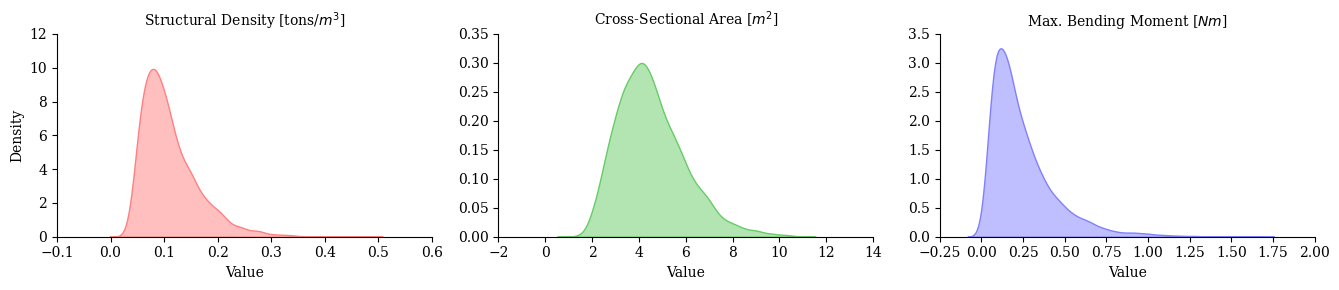

In [8]:
#Let's plot a kde of each of the Y_data columns

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '10' 

colors = [[1,.5,.5], 
          [.4,.8,.4], 
          [.5,.5,1],
          [1,.5,.5],
          [.4,.8,.4],
          [.5,.5,1]]

idx = [2, 6, 11]  # Indices of the columns to plot
columns_to_plot = df_columns[idx]

Y_data_subset = Y_data.melt(id_vars=None, value_vars=columns_to_plot, var_name='Structural Property', value_name='Val')

#Rename the columns in Y_data_subset for clarity
Y_data_subset['Structural Property'] = Y_data_subset['Structural Property'].replace({
    'Unit_Steel_Weight [tons/m^3]': r'Structural Density [tons/$m^3$]',
    r'Cross_Sectional_Area [m^2]': r'Cross-Sectional Area [$m^2$]',
     'Max_Bending_Moment [Nm]': r'Max. Bending Moment [$Nm$]'
})

#create new df with log values
Y_log = Y_data_subset.copy()
Y_log['Val'] = np.log(Y_log['Val'])

#rename items in 'Structural Property' column for clarity
Y_log['Structural Property'] = Y_log['Structural Property'].replace({
    r'Structural Density [tons/$m^3$]' : 'Log(Structural Density)',
    r'Cross-Sectional Area [$m^2$]' : 'Log(Cross-Sectional Area)',
    r'Max. Bending Moment [$Nm$]' : r'Log(Max. Bending Moment)'
  
})

#concatenate the original and log dataframes
#Y_data_subset = pd.concat([Y_data_subset, Y_log], ignore_index=True)


#now make a kde plot in. facetgrid. one row is 'Value' and the other row is 'Log Value'
g = sns.FacetGrid(Y_data_subset, col='Structural Property', sharex=False, sharey=False, height=3, aspect=1.5, col_wrap=3)

for ax, color, var in zip(g.axes.flatten(), colors, Y_data_subset["Structural Property"].unique()):
    sns.kdeplot(
        data=Y_data_subset[Y_data_subset["Structural Property"] == var],
        x="Val",
        fill=True,
        ax=ax,
        color=color,
        alpha=0.5
    )
    ax.ticklabel_format(style='sci', axis='y')
    #mu, std = Y_data_subset[Y_data_subset["Structural Property"] == var]["Val"].mean(), Y_data_subset[Y_data_subset["Structural Property"] == var]["Val"].std()
    #x = np.linspace(mu - 3*std, mu + 3*std, 100)
    #ax.plot(x, norm.pdf(x,mu,std), color=(0.3,0.3,0.3),linewidth = 0.85, linestyle='--', label=r'Normal Dist. Around $\mu, \sig$ of Data')

g.set_axis_labels("Value", "Density", fontsize=10)
#format scinetific notati

g.set_xticklabels(fontsize=10)
g.set_yticklabels(fontsize=10)
g.set_titles("{col_name}")
#plt.legend()
plt.tight_layout()


plt.savefig('./Figures/Performance_Metrics_Range.png', dpi=450)
plt.show()





    

# Machine Learning #

## Set up ML Training 

In [9]:
#Load X Data info: 
path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'
error_idx = np.loadtxt(f"{path}/random_test_design_error_idx_All.csv", delimiter=',', dtype=int)

#Load X Data:
X_data = pd.read_csv(path + '/random_test_design_Parameters_All.csv')

#Load y Data:
Y_data = pd.read_csv(path + '/random_test_design_Structural_Properties.csv')

#Remove error indices from X_data and Y_data
X_data = X_data.drop(index=error_idx)
Y_data = Y_data.drop(index=error_idx)

#check if the number of samples match
if X_data.shape[0] != Y_data.shape[0]:
    raise ValueError("Number of samples in X_data and Y_data do not match after removing error indices.")



Y_s = np.log(Y_data[df_columns[[2,6,11]]].values)
X_s = X_data.values

def feature_engineer_X(X):
    #Feature Engineering: Lets get some known ratios examined and square all terms to get better performance from the MLP.
    X_ratios = np.array( [X[:,0]/X[:,15], # Ratio of length to N webframes
                          X[:,0]/X[:,92], #Ratio of length to N frames
                          X[:,1]/X[:,16],  # Ratio of Beam to N bottom girders
                          X[:,1]/X[:,17], #Ratio of Beam to N bottom stiffeners
                          X[:,1]/X[:,18], #Ratio of Beam to N deck girders
                          X[:,1]/X[:,19], #Ratio of Beam to N deck stiffeners
                          X[:,1]/X[:,21], #Ratio of Beam to N vertical bulkhead stiffeners
                          X[:,3]/X[:,20], #Ratio of depth to N side shell stiffeners
                          X[:,3]/X[:,22] ]).transpose() # Ratio of depth to N horizontal bulkhead stiffeners])



    #concatenate the original with squared values of x
    X = np.concatenate((X, 
                          X_ratios
                          ), axis=1)

    X = np.concatenate((X, X**2), axis=1)
    
    return X





In [10]:
Y_scaler_obj = StandardScaler()
#Y_scaler = MinMaxScaler()

Y = Y_scaler_obj.fit_transform(Y_s)

print("Y shape:", Y.shape)
y_labels = [r'Structural Density [tons/$m^3$]', r'Cross-Sectional Area [$m^2$]', r'Max. Bending Moment [$Nm$]']

X_param_scaler = StandardScaler()
X_p = X_param_scaler.fit_transform(X_s)


Y shape: (5024, 3)


In [11]:
#Create a data loader function
def create_data_loader(X, labels, batch_size):
    dataset = torch.utils.data.TensorDataset(torch.tensor(X).float().to(device), torch.tensor(labels).float())
    data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return data_loader


split = 0.8
batch_size = 128


In [13]:
# Train Parametric Model: 

X_p_train, X_p_test = X_p[:int(split*len(X_p))], X_p[int(split*len(X_p)):]
Y_train, Y_test = Y[:int(split*len(Y))], Y[int(split*len(Y)):]
data_loader_1 = create_data_loader(X_p_train, Y_train, batch_size)

y_test_len = len(Y_test)

Y_results = np.zeros((y_test_len, Y.shape[1]))



model_1 = MLP(len(X_p[0]), [128,128], len(Y[0]))
model_1.to(device)
model_1.train()

optimizer = torch.optim.Adam(model_1.parameters(), lr=0.0001)
criteria = nn.MSELoss()

num_epochs = 1000
import time

start = time.time()

for epoch in tqdm(range(num_epochs)):
    for X_batch, Y_batch in data_loader_1:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)
        optimizer.zero_grad()
        output = model_1(X_batch)
        loss = criteria(output, Y_batch)
        loss.backward()
        optimizer.step()
    if(epoch % 500 == 0):
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}')

mid = time.time()
# Test the model
X_p_test = torch.tensor(X_p_test).float().to(device)
model_1.eval()
output = model_1(X_p_test).cpu().detach().numpy()

output_scaled = np.exp(Y_scaler_obj.inverse_transform(output))
Y_test_scaled = np.exp(Y_scaler_obj.inverse_transform(Y_test))
end = time.time()

print(f"Training time: {mid - start} seconds")
print(f"Testing time: {end - mid} seconds")

  0%|          | 5/1000 [00:00<00:46, 21.51it/s]

Epoch 1/1000, Loss: 0.8335689902305603


 50%|█████     | 503/1000 [00:22<00:24, 20.01it/s]

Epoch 501/1000, Loss: 0.05218546837568283


100%|██████████| 1000/1000 [00:44<00:00, 22.72it/s]

Training time: 44.01971888542175 seconds
Testing time: 0.0012950897216796875 seconds


In [14]:
# Calculate R2
from sklearn.metrics import r2_score

R2 = np.zeros((len(Y[0]),))

for i in range(3):
    R2[i] = r2_score(Y_test_scaled[:,i], output_scaled[:,i])

print('R2:', R2)

R2: [0.96891527 0.92010556 0.97380078]


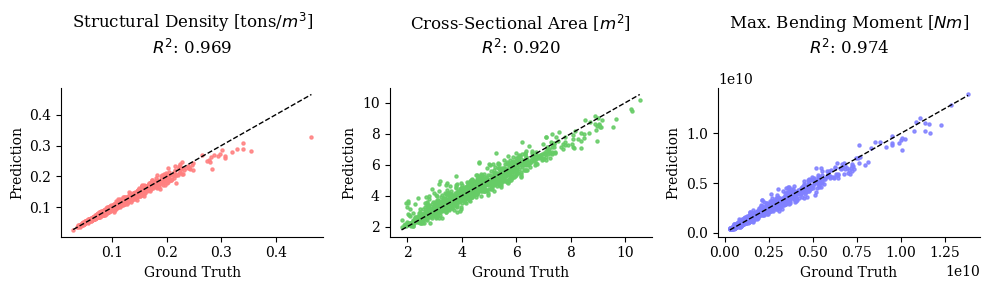

In [15]:


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '10' 

colors = [[1,.5,.5], [.4,0.8,.4], [.5,.5,1]]

#Make three subplots that show the regression versus ground truth for the test set and put the R2 score in the title
fig, axs = plt.subplots(1, 3, figsize=(10,3))

#plt.suptitle('Regression Accuracy For Surrogate Models')
for ax, color, i in zip(axs, colors, list(range(3))):
    
    ax.plot([Y_test_scaled[:,i].min(), Y_test_scaled[:,i].max()], [Y_test_scaled[:,i].min(), Y_test_scaled[:,i].max()], 'k--', alpha = 1, lw=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.scatter(Y_test_scaled[:,i], output_scaled[:,i], color=color, marker='o', alpha=0.85, s=5 )
    ax.set_xlabel('Ground Truth')
    ax.set_ylabel('Prediction')
    ax.set_title(f'{y_labels[i]}\n' + r'$R^2$: ' + f'{R2[i]:.3f}', pad=25)



plt.tight_layout()

#plt.savefig('./Figures/Performance_Metrics_Regression.png', dpi=450)

plt.show()

## Now let's look at the Constraints ##


In [16]:
# First lets load the constraint thresholds and values and plot the constraint violations for the test set.

path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'

constraint_thresholds = pd.read_csv(f"{path}/random_test_design_Constraint_Thresholds.csv")
constraint_evals = pd.read_csv(f"{path}/random_test_design_Constraint_Values.csv")

#constraint_diff = -(constraint_thresholds - constraint_evals)/(constraint_thresholds+1e-2) # Goal is to get negative
constraint_diff = constraint_thresholds - constraint_evals # Goal is to get negative



#clip to median+/- 2 sigma for each category
med = constraint_diff.median(axis=0)

sigma = constraint_diff.std(axis=0)
print(sigma.shape)

constraint_diff = constraint_diff.clip(med - 2*sigma, med + 2*sigma, axis=1)
print(constraint_diff.shape)

#first melt each dataframe to have columns for 'constraint_name', a column for index and a column for 'Value'
constraint_thresholds_melted = constraint_thresholds.melt(id_vars=None, var_name='Constraint', value_name='Value')
constraint_evals_melted = constraint_evals.melt(id_vars=None, var_name='Constraint', value_name='Value')

constraint_diff_melted = constraint_diff.melt(id_vars=None, var_name='Constraint', value_name='Value')




(23,)
(5050, 23)


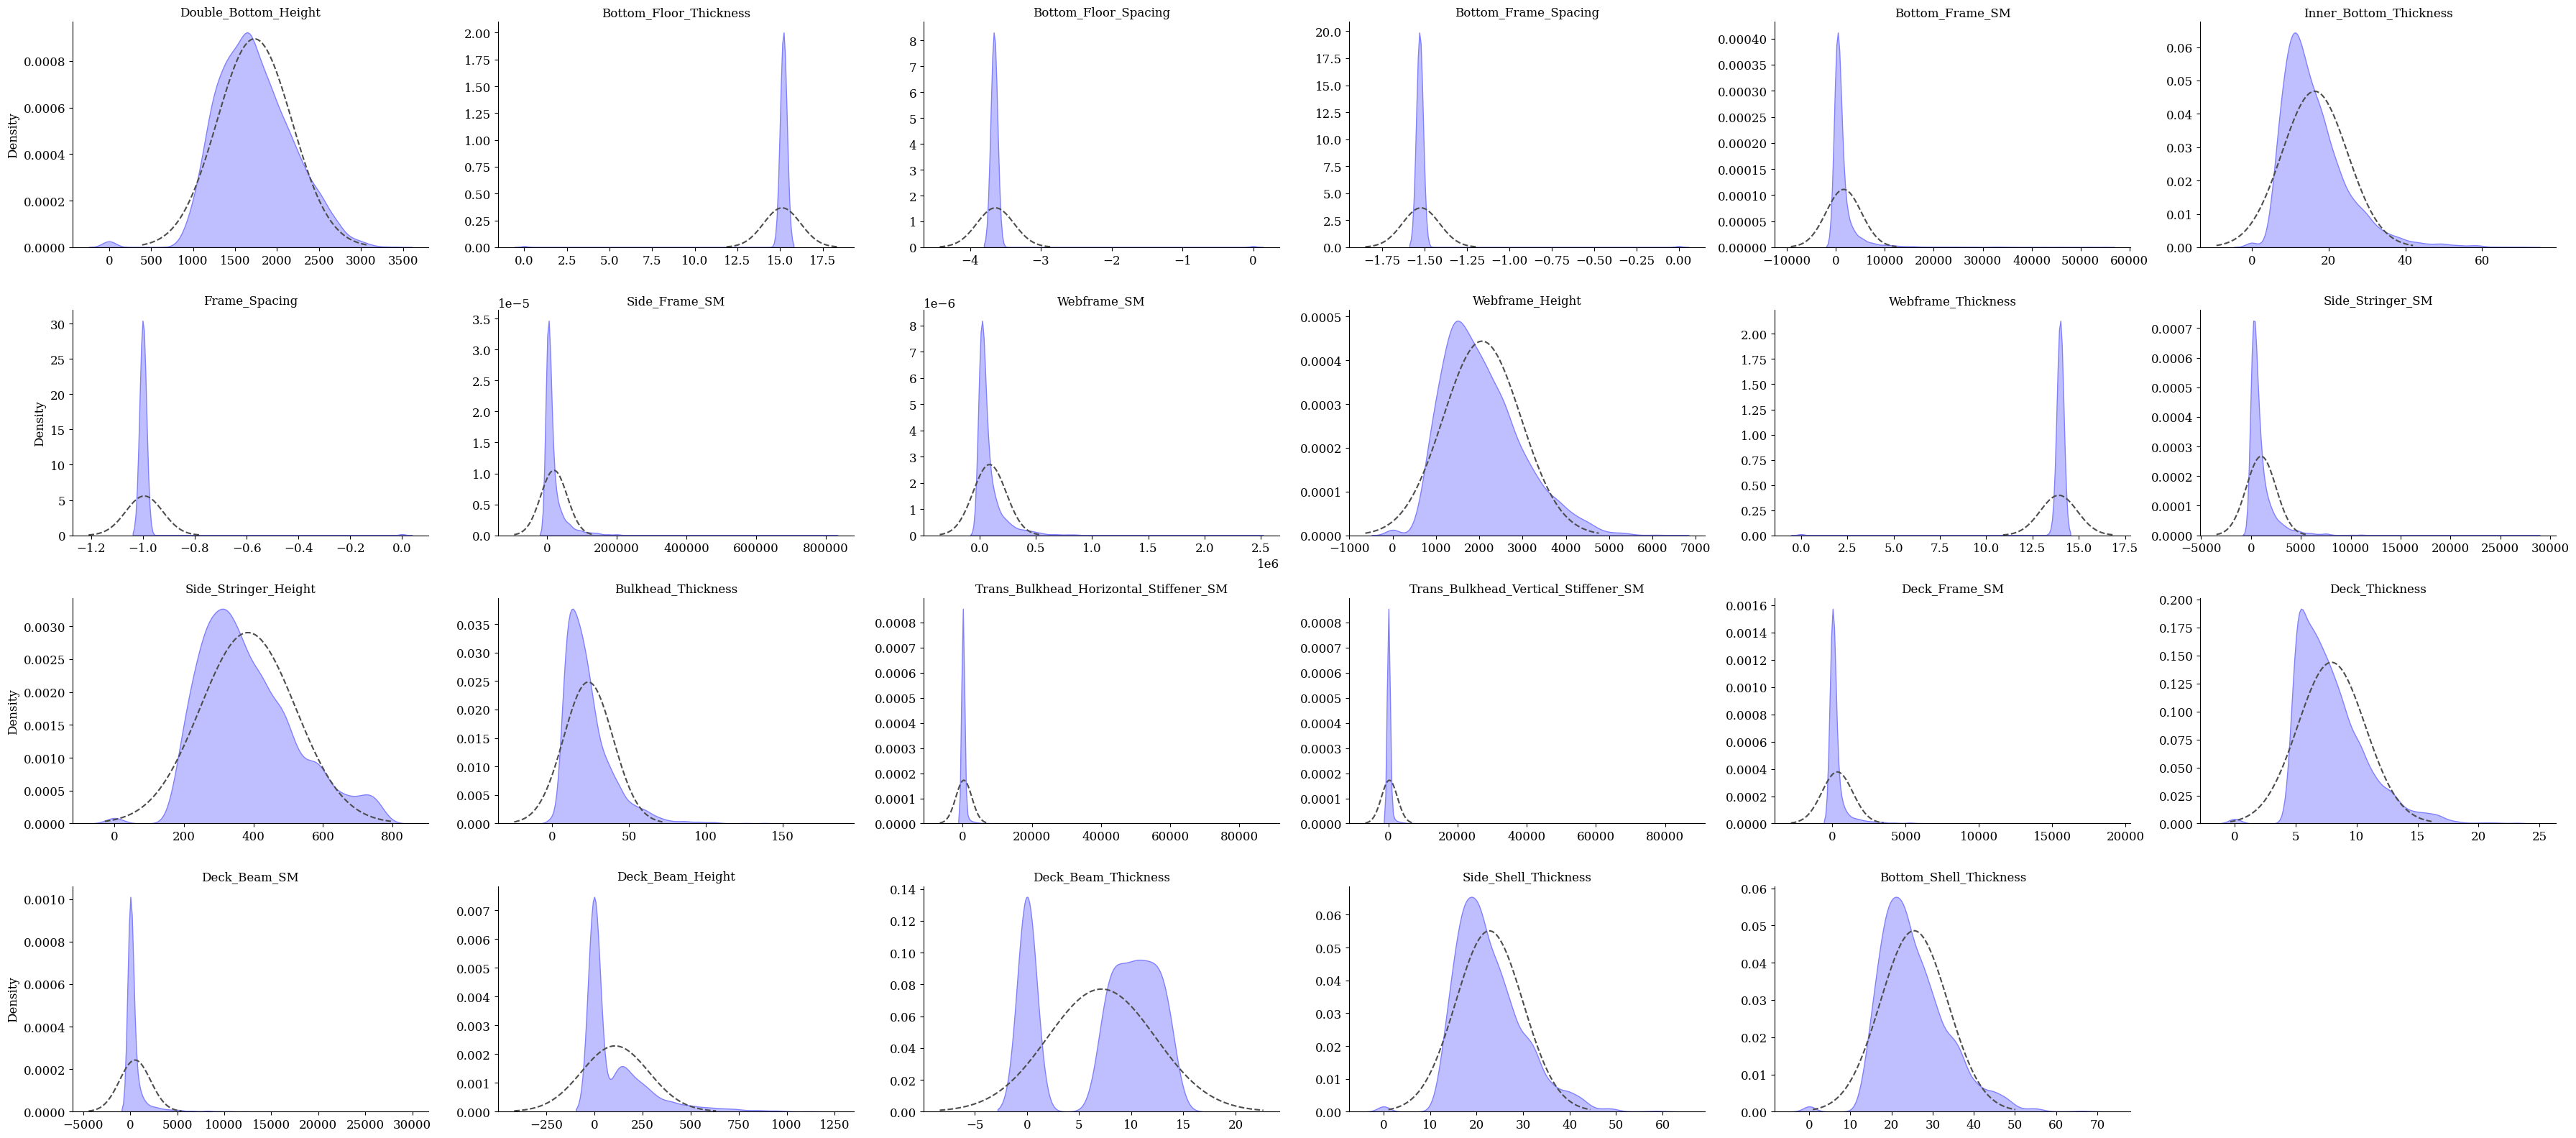

In [19]:
#plot the constraint thresholds as a kde with a normal curve in a facetgrid in a 6x4 grid 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12' 



g = sns.FacetGrid(constraint_thresholds_melted, col='Constraint', sharex=False, sharey=False, height=4, aspect=1.5, col_wrap=6)

for ax, var in zip(g.axes.flatten(),constraint_thresholds_melted['Constraint'].unique()):
    sns.kdeplot(
        data=constraint_thresholds_melted[constraint_thresholds_melted["Constraint"] == var],
        x="Value",
        fill=True,
        ax=ax,
        color=[0.5,0.5,1.0],
        alpha=0.5
    )
    mu, std = constraint_thresholds_melted[constraint_thresholds_melted["Constraint"] == var]["Value"].mean(), constraint_thresholds_melted[constraint_thresholds_melted["Constraint"] == var]["Value"].std()
    x = np.linspace(mu - 3*std, mu + 3*std, 100)
    ax.plot(x, norm.pdf(x,mu,std), color=(0.3,0.3,0.3), linestyle='--', label=r'Normal Dist. Around $\mu, \sig$ of Data')

g.set_axis_labels("", "Density")
g.set_titles("{col_name}")
#plt.legend()
plt.tight_layout()
plt.show()


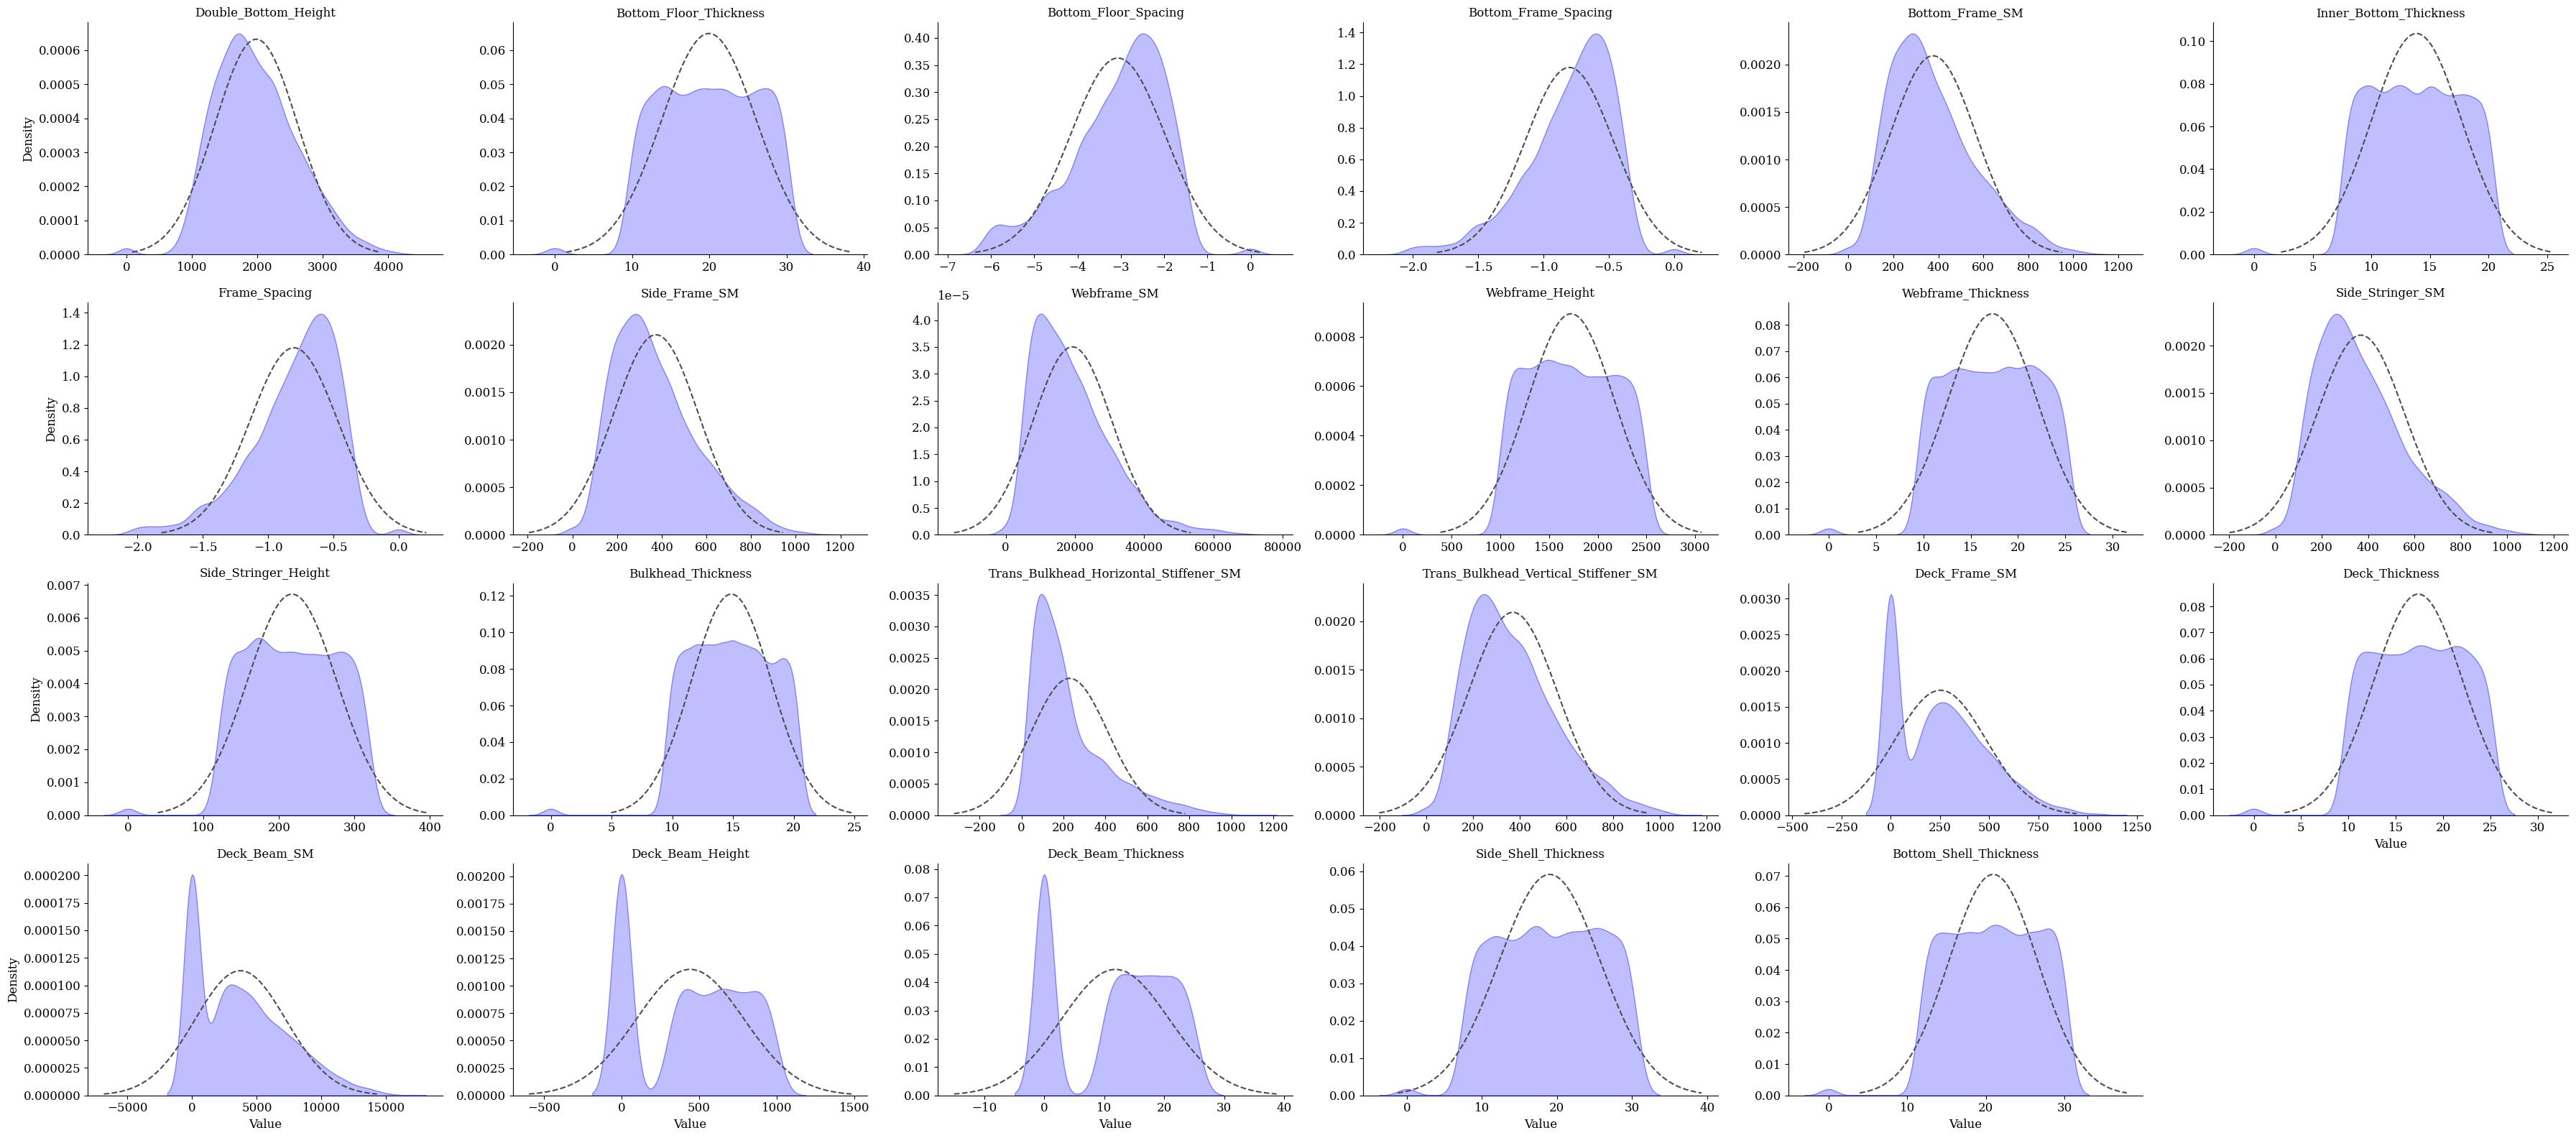

In [20]:
# Now lets repeat for the constraint evaluations. We can also plot the constraint violations by plotting the difference between the evaluation and the threshold for each constraint.
#plot the constraint thresholds as a kde with a normal curve in a facetgrid in a 6x4 grid 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12' 



g = sns.FacetGrid(constraint_evals_melted, col='Constraint', sharex=False, sharey=False, height=4, aspect=1.5, col_wrap=6)

for ax, var in zip(g.axes.flatten(),constraint_evals_melted['Constraint'].unique()):
    sns.kdeplot(
        data=constraint_evals_melted[constraint_evals_melted["Constraint"] == var],
        x="Value",
        fill=True,
        ax=ax,
        color=[0.5,0.5,1.0],
        alpha=0.5
    )
    mu, std = constraint_evals_melted[constraint_evals_melted["Constraint"] == var]["Value"].mean(), constraint_evals_melted[constraint_evals_melted["Constraint"] == var]["Value"].std()
    x = np.linspace(mu - 3*std, mu + 3*std, 100)
    ax.plot(x, norm.pdf(x,mu,std), color=(0.3,0.3,0.3), linestyle='--', label=r'Normal Dist. Around $\mu, \sig$ of Data')

g.set_axis_labels("Value", "Density")
g.set_titles("{col_name}")
#plt.legend()
plt.tight_layout()
plt.show()



Double_Bottom_Height, Feasibility Rate: 0.8378
Bottom_Floor_Thickness, Feasibility Rate: 0.718
Bottom_Floor_Spacing, Feasibility Rate: 0.7327
Bottom_Frame_Spacing, Feasibility Rate: 1.0
Bottom_Frame_SM, Feasibility Rate: 0.4238
Inner_Bottom_Thickness, Feasibility Rate: 0.4469
Frame_Spacing, Feasibility Rate: 0.7604
Side_Frame_SM, Feasibility Rate: 0.1109
Webframe_SM, Feasibility Rate: 0.3105
Webframe_Height, Feasibility Rate: 0.4079
Webframe_Thickness, Feasibility Rate: 0.7473
Side_Stringer_SM, Feasibility Rate: 0.3721
Side_Stringer_Height, Feasibility Rate: 0.1123
Bulkhead_Thickness, Feasibility Rate: 0.3325
Trans_Bulkhead_Horizontal_Stiffener_SM, Feasibility Rate: 0.8808
Trans_Bulkhead_Vertical_Stiffener_SM, Feasibility Rate: 0.8784
Deck_Frame_SM, Feasibility Rate: 0.7952
Deck_Thickness, Feasibility Rate: 0.9669
Deck_Beam_SM, Feasibility Rate: 0.9693
Deck_Beam_Height, Feasibility Rate: 0.9687
Deck_Beam_Thickness, Feasibility Rate: 0.9376
Side_Shell_Thickness, Feasibility Rate: 0.3745

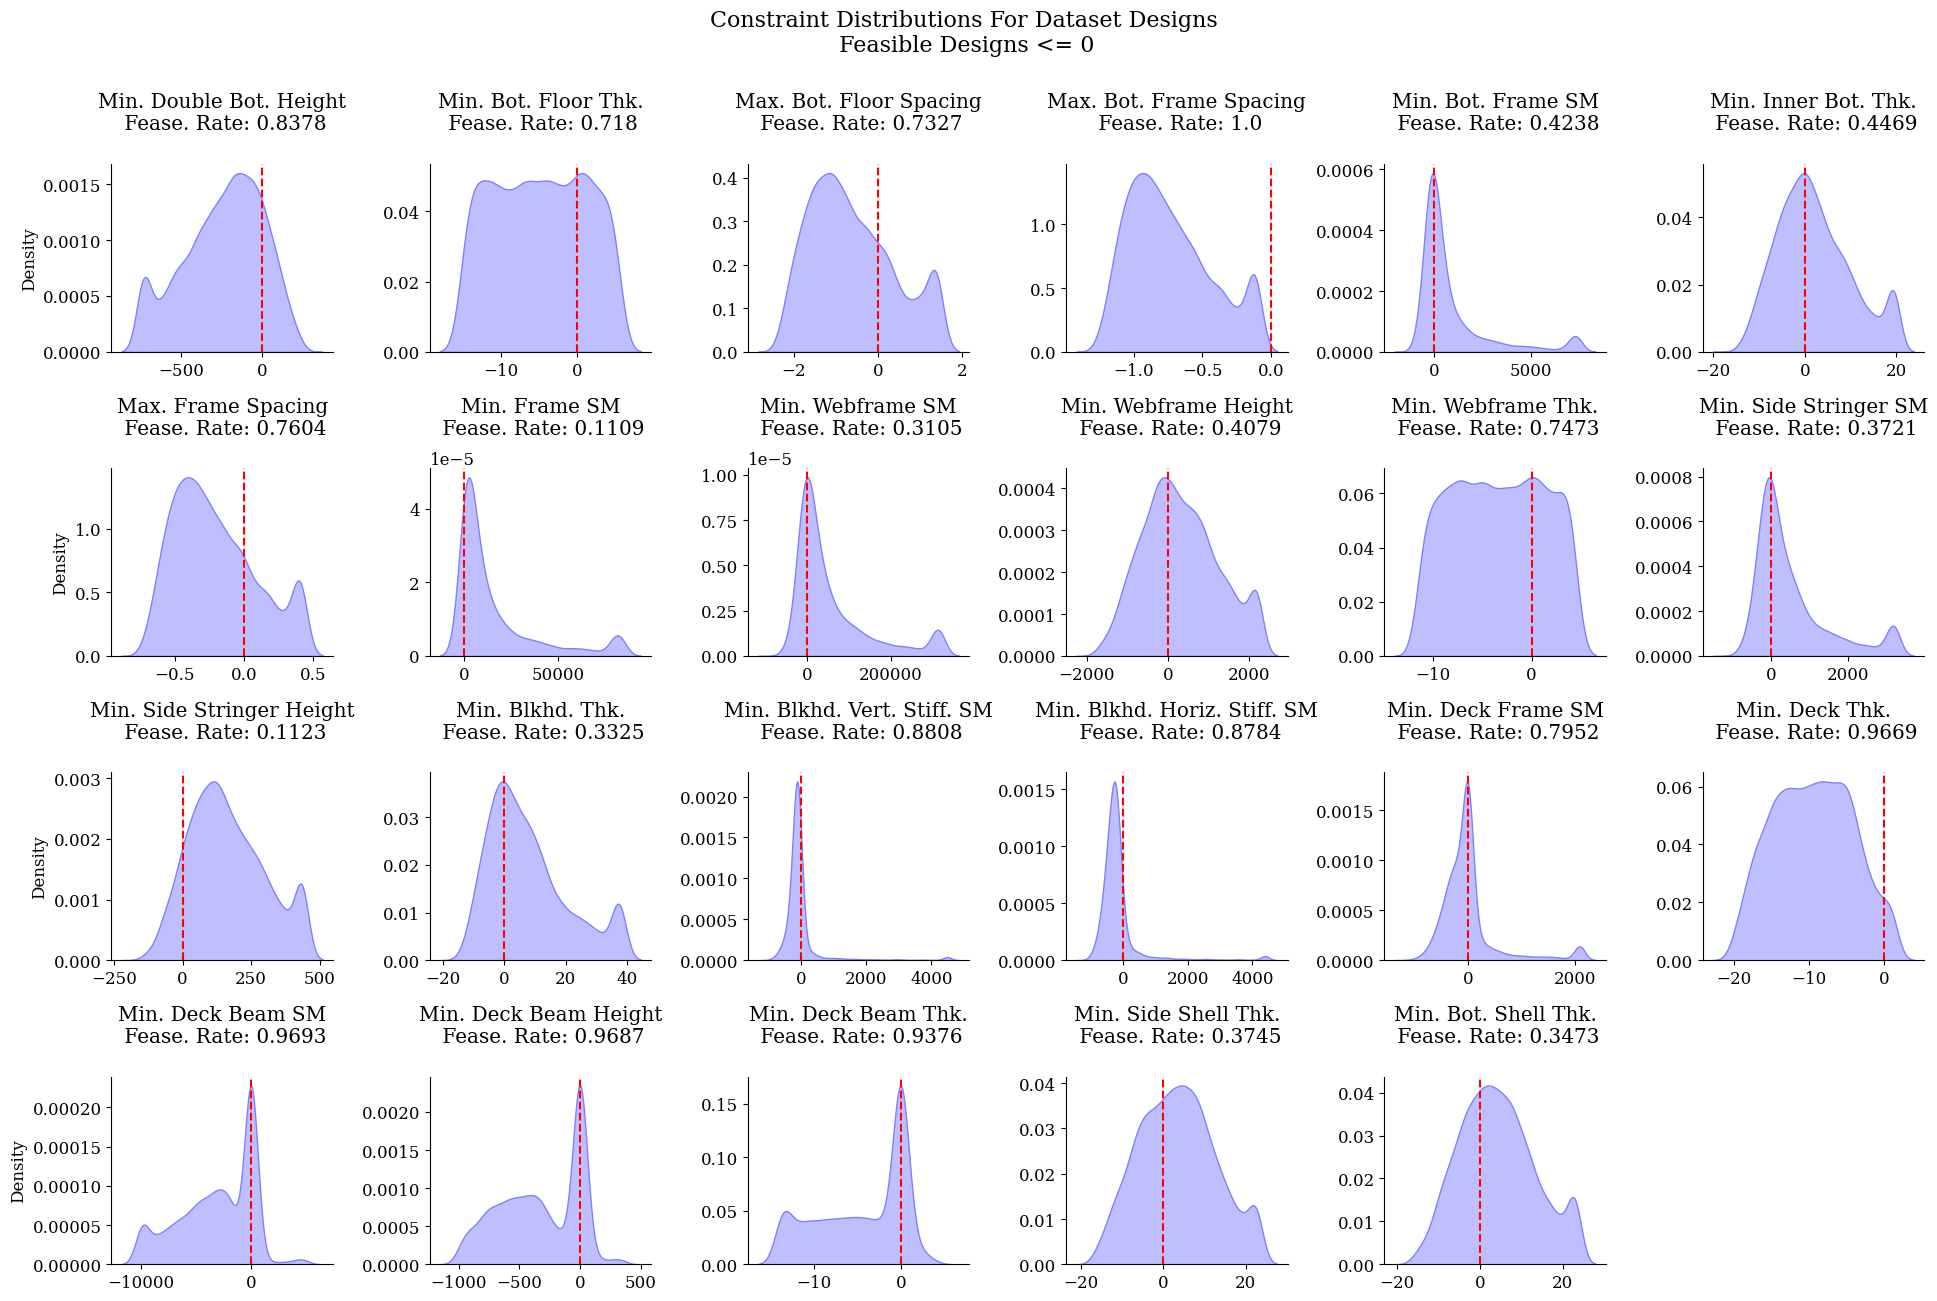

Max Feasebility Rate: 1.0
Min Feasebility Rate: 0.11089108910891089
mean Feasebility Rate: 0.6274730951356006
Cumulative Feasibility Rate: 6.304048042620179e-07


In [25]:
# Now let's plot the differene 

constraint_names = np.array([
    "Min. Double Bot. Height",
    "Min. Bot. Floor Thk.",
    "Max. Bot. Floor Spacing",
    "Max. Bot. Frame Spacing",
    "Min. Bot. Frame SM",
    "Min. Inner Bot. Thk.",
    "Max. Frame Spacing",
    "Min. Frame SM",
    "Min. Webframe SM",
    "Min. Webframe Height",
    "Min. Webframe Thk.",
    "Min. Side Stringer SM",
    "Min. Side Stringer Height",
    "Min. Blkhd. Thk.",
    "Min. Blkhd. Vert. Stiff. SM",
    "Min. Blkhd. Horiz. Stiff. SM",
    "Min. Deck Frame SM",
    "Min. Deck Thk.",
    "Min. Deck Beam SM",
    "Min. Deck Beam Height",
    "Min. Deck Beam Thk.",
    "Min. Side Shell Thk.",
    "Min. Bot. Shell Thk."
])

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12'

g = sns.FacetGrid(constraint_diff_melted, col='Constraint', sharex=False, sharey=False, height=3.25, col_wrap=6)

for ax, var in zip(g.axes.flatten(),constraint_diff_melted['Constraint'].unique()):
    sns.kdeplot(
        data=constraint_diff_melted[constraint_diff_melted["Constraint"] == var],
        x="Value",
        fill=True,
        ax=ax,
        color=[0.5,0.5,1.0],
        alpha=0.5
    )
    mu, std = constraint_diff_melted[constraint_diff_melted["Constraint"] == var]["Value"].mean(), constraint_diff_melted[constraint_diff_melted["Constraint"] == var]["Value"].std()
    x = np.linspace(mu - 3*std, mu + 3*std, 100)
    #Plot a vertical line at x=0 to show the boundary between satisfied and violated constraints
    ax.axvline(x=0, color='r', linestyle='--', label='Constraint Boundary')
    #ax.plot(x, norm.pdf(x,mu,std), color=(0.3,0.3,0.3), linestyle='--', label=r'Normal Dist. Around $\mu, \sig$ of Data')
feas_rates = []
#Get percent of samples that satisfy each constraint and put it in the title of each subplot
for ax, var, i in zip(g.axes.flatten(),constraint_diff_melted['Constraint'].unique(), np.arange(len(constraint_diff_melted['Constraint'].unique()))):
    total_samples = len(constraint_diff_melted[constraint_diff_melted["Constraint"] == var])
    satisfied_samples = len(constraint_diff_melted[(constraint_diff_melted["Constraint"] == var) & (constraint_diff_melted["Value"] <= 0)])
    fease_rate = satisfied_samples / total_samples
    ax.set_title(constraint_names[i] + f'\n Fease. Rate: {fease_rate:.4}', pad=25)
    print(f'{var}, Feasibility Rate: {fease_rate:.4}')
    feas_rates.append(fease_rate)

#Make super title
g.fig.suptitle('Constraint Distributions For Dataset Designs \n Feasible Designs <= 0 ', fontsize=16, y=1)

g.set_axis_labels("", "Density", fontsize=12)
#g.set_titles("{col_name}")
#plt.legend()
plt.tight_layout()
plt.savefig('./Figures/ABS_Cons.png', dpi=450)
plt.show()


print('Max Feasebility Rate:', max(feas_rates))
print('Min Feasebility Rate:', min(feas_rates))
print('mean Feasebility Rate:', np.mean(feas_rates))
# Cumulative Feasiblity Rate: 
print('Cumulative Feasibility Rate:', np.prod(feas_rates))



## Now let's train a constraint ML ##

we are going to train a model to predict contraint difference from parameters

In [26]:
# what we care about is the ability to predict whether the constraints are satisfied or not

#write function to check 

def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    # we want the rate: 
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate
    TNR = TN / (TN + FP) if (TN + FP) > 0 else 0  # True Negative Rate
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0  # False Positive Rate
    FNR = FN / (TP + FN) if (TP + FN) > 0 else 0  # False Negative Rate
    return TPR, TNR, FPR, FNR


In [27]:
#Load X Data info: 
path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'

error_idx = np.loadtxt(f"{path}/random_test_design_error_idx_All.csv", delimiter=',', dtype=int)

#Load X Data:
X_data = pd.read_csv(path + '/random_test_design_Parameters_All.csv')


#Load y Data:
constraint_thresholds = pd.read_csv(f"{path}/random_test_design_Constraint_Thresholds.csv")
constraint_evals = pd.read_csv(f"{path}/random_test_design_Constraint_Values.csv")

Y_data = constraint_thresholds - constraint_evals

#clip to mu +/- 2 sigma for each category
med = Y_data.median(axis=0)
sigma = Y_data.std(axis=0)
Y_data = Y_data.clip(med - 2*sigma, med + 2*sigma, axis=1)

Y_cls = (Y_data <= 0).astype(int) # 1 if constraint is satisfied, 0 if violated



#Remove error indices from X_data and Y_data
X_data = X_data.drop(index=error_idx)
Y_data = Y_data.drop(index=error_idx)
Y_cls = Y_cls.drop(index=error_idx)

#check if the number of samples match
if X_data.shape[0] != Y_data.shape[0]:
    raise ValueError("Number of samples in X_data and Y_data do not match after removing error indices.")

Y_s = Y_data.values

X_s = X_data.values


#Try cube rooting the y_values in columns with SM to see if it improves predictions
#Y_s[:,[4,7,8,11,14,15,16,18]] = np.cbrt(Y_s[:,[4,7,8,11,14,15,16,18]])


y_labels = Y_data.columns.values

In [34]:
Y_scaler0 = RobustScaler()
Y_scaler1 = MinMaxScaler()

Y_scaler_R = RobustScaler()


Y = Y_scaler1.fit_transform(Y_scaler0.fit_transform(Y_s))
Y_zeros = Y_scaler1.transform(Y_scaler0.transform(np.zeros((1, Y_s.shape[1]))))


#Y = Y_scaler_R.fit_transform(Y_s)
#Y_zeros = Y_scaler_R.transform(np.zeros((1, Y_s.shape[1])))
print("Y zeros:", Y_zeros)

print("Y shape:", Y.shape)


X_param_scaler = StandardScaler()
X_p = X_param_scaler.fit_transform(X_s)


Y zeros: [[0.75439571 0.74       0.62495096 1.10213346 0.12231197 0.44675932
  0.64036493 0.01117812 0.17833142 0.44527771 0.74060991 0.2370318
  0.25344499 0.27177304 0.17719964 0.19660688 0.34020021 0.94650046
  0.68043571 0.75097943 0.77586348 0.41421213 0.40474637]]
Y shape: (5024, 23)


In [35]:
Y_zeros = torch.tensor(Y_zeros).float().to(device)

# Define the class imbalance weights as num Neg/num Pos for each constraint
w_cls_imb = torch.tensor(Y_cls.sum(axis=0) / (len(Y_cls) - Y_cls.sum(axis=0)) + 1e-6).float().to(device) # Add a small constant to avoid division by zero

def custom_loss(y_pred, y_true):
    #w = 1.0 + 1.0/(torch.abs(y_true - Y_zeros) + 1e-1)# Add a small constant to avoid division by zero Y_zeros is the scaled value of a true Y=O. we want weight the accuracy values near zero better predictions near the constraint boundary more heavily.
    w = 1.0
    L_reg = nn.MSELoss(reduction='none')(y_pred, y_true)
    L_cls = nn.BCEWithLogitsLoss(reduction='none')((y_pred<=Y_zeros).float(), (y_true<=Y_zeros).float())
    
    #print((w*L_reg + alpha*L_cls).shape)
    return torch.mean(w*L_reg) + torch.mean(w_cls_imb*L_cls)
 

/var/folders/6c/7y2jzhfd6t3750c02xt1gxl00000gn/T/ipykernel_32987/1622832491.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  w_cls_imb = torch.tensor(Y_cls.sum(axis=0) / (len(Y_cls) - Y_cls.sum(axis=0)) + 1e-6).float().to(device) # Add a small constant to avoid division by zero


In [38]:
split = 0.8
batch_size = 256

# Train Parametric Model: 

X_p_train, X_p_test = X_p[:int(split*len(X_p))], X_p[int(split*len(X_p)):]
Y_train, Y_test = Y[:int(split*len(Y))], Y[int(split*len(Y)):]
data_loader_1 = create_data_loader(X_p_train, Y_train, batch_size)

y_test_len = len(Y_test)

Y_results = np.zeros((y_test_len, Y.shape[1]))



model_cons = MLP(len(X_p[0]), [128,128,128], len(Y[0]))
model_cons.to(device)
model_cons.train()

optimizer = torch.optim.Adam(model_cons.parameters(), lr=0.0001)
criteria = nn.MSELoss()
#criteria = nn.HuberLoss()

#criteria = custom_loss

num_epochs = 1000

for epoch in tqdm(range(num_epochs)):
    for X_batch, Y_batch in data_loader_1:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)
        optimizer.zero_grad()
        output = model_cons(X_batch)
        loss = criteria(output, Y_batch)
        loss.backward()
        optimizer.step()
    if(epoch % 500 == 0):
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}')


# Test the model
X_p_test = torch.tensor(X_p_test).float().to(device)
model_cons.eval()
output = model_cons(X_p_test).cpu().detach().numpy()

output_scaled = Y_scaler0.inverse_transform(Y_scaler1.inverse_transform(output))
Y_test_scaled = Y_scaler0.inverse_transform(Y_scaler1.inverse_transform(Y_test))

#output_scaled = Y_scaler_R.inverse_transform(output)
#Y_test_scaled = Y_scaler_R.inverse_transform(Y_test)



  0%|          | 3/1000 [00:00<01:16, 13.11it/s]

Epoch 1/1000, Loss: 0.2274758219718933


 50%|█████     | 504/1000 [00:21<00:20, 24.31it/s]

Epoch 501/1000, Loss: 0.012020113877952099


100%|██████████| 1000/1000 [00:44<00:00, 22.70it/s]


In [41]:
#lets check the confusion matrix for the constriants as accurately predicting 
# also import F1 score from sklearn
from sklearn.metrics import f1_score

# We want 
output_binary = (output_scaled <= 0.0).astype(int)
Y_test_binary = (Y_test_scaled <= 0.0).astype(int)

for i in range(Y.shape[1]):
    TPR, TNR, FPR, FNR = confusion_matrix(Y_test_binary[:,i], output_binary[:,i])
    print(f'Constraint: {y_labels[i]}, TPR: {TPR:.3f}, TNR: {TNR:.3f}, FPR: {FPR:.3f}, FNR: {FNR:.3f}')
    f1 = f1_score(Y_test_binary[:,i], output_binary[:,i])
    print(f'Constraint: {y_labels[i]}, F1 Score (Feas. Class): {f1:.3f}')

    f1_viol = f1_score(Y_test_binary[:,i], output_binary[:,i], pos_label=0)
    print(f'Constraint: {y_labels[i]}, F1 Score (Infeas. Class): {f1_viol:.3f}')




Constraint: Double_Bottom_Height, TPR: 0.996, TNR: 0.497, FPR: 0.503, FNR: 0.004
Constraint: Double_Bottom_Height, F1 Score (Feas. Class): 0.952
Constraint: Double_Bottom_Height, F1 Score (Infeas. Class): 0.656
Constraint: Bottom_Floor_Thickness, TPR: 0.995, TNR: 0.824, FPR: 0.176, FNR: 0.005
Constraint: Bottom_Floor_Thickness, F1 Score (Feas. Class): 0.966
Constraint: Bottom_Floor_Thickness, F1 Score (Infeas. Class): 0.896
Constraint: Bottom_Floor_Spacing, TPR: 0.969, TNR: 0.888, FPR: 0.112, FNR: 0.031
Constraint: Bottom_Floor_Spacing, F1 Score (Feas. Class): 0.965
Constraint: Bottom_Floor_Spacing, F1 Score (Infeas. Class): 0.898
Constraint: Bottom_Frame_Spacing, TPR: 0.999, TNR: 0.000, FPR: 0.000, FNR: 0.001
Constraint: Bottom_Frame_Spacing, F1 Score (Feas. Class): 1.000
Constraint: Bottom_Frame_Spacing, F1 Score (Infeas. Class): 0.000
Constraint: Bottom_Frame_SM, TPR: 0.827, TNR: 0.894, FPR: 0.106, FNR: 0.173
Constraint: Bottom_Frame_SM, F1 Score (Feas. Class): 0.840
Constraint: Bot

In [42]:
#Calculate R2
from sklearn.metrics import r2_score
R2 = np.zeros((len(Y[0]),))

Y_test_scaled_no_outliers = []
output_scaled_no_outliers = []

for i in range(len(Y[0])):
    # First we want to remove the outliers from the test set for this constraint
    diff = Y_test_scaled[:,i]-output_scaled[:,i]
    outlier_idx = np.where(diff > 5*np.std(diff))[0]
    print(f"Constraint: {y_labels[i]}, Outliers removed: {len(outlier_idx)}")
    Y_test_scaled_no_outliers.append(np.delete(Y_test_scaled[:,i], outlier_idx))
    output_scaled_no_outliers.append(np.delete(output_scaled[:,i], outlier_idx))

    R2[i] = r2_score(Y_test_scaled_no_outliers[i], output_scaled_no_outliers[i])

print('R2:', R2)



Constraint: Double_Bottom_Height, Outliers removed: 0
Constraint: Bottom_Floor_Thickness, Outliers removed: 0
Constraint: Bottom_Floor_Spacing, Outliers removed: 0
Constraint: Bottom_Frame_Spacing, Outliers removed: 0
Constraint: Bottom_Frame_SM, Outliers removed: 5
Constraint: Inner_Bottom_Thickness, Outliers removed: 0
Constraint: Frame_Spacing, Outliers removed: 0
Constraint: Side_Frame_SM, Outliers removed: 2
Constraint: Webframe_SM, Outliers removed: 1
Constraint: Webframe_Height, Outliers removed: 0
Constraint: Webframe_Thickness, Outliers removed: 0
Constraint: Side_Stringer_SM, Outliers removed: 2
Constraint: Side_Stringer_Height, Outliers removed: 0
Constraint: Bulkhead_Thickness, Outliers removed: 1
Constraint: Trans_Bulkhead_Horizontal_Stiffener_SM, Outliers removed: 11
Constraint: Trans_Bulkhead_Vertical_Stiffener_SM, Outliers removed: 10
Constraint: Deck_Frame_SM, Outliers removed: 7
Constraint: Deck_Thickness, Outliers removed: 0
Constraint: Deck_Beam_SM, Outliers removed

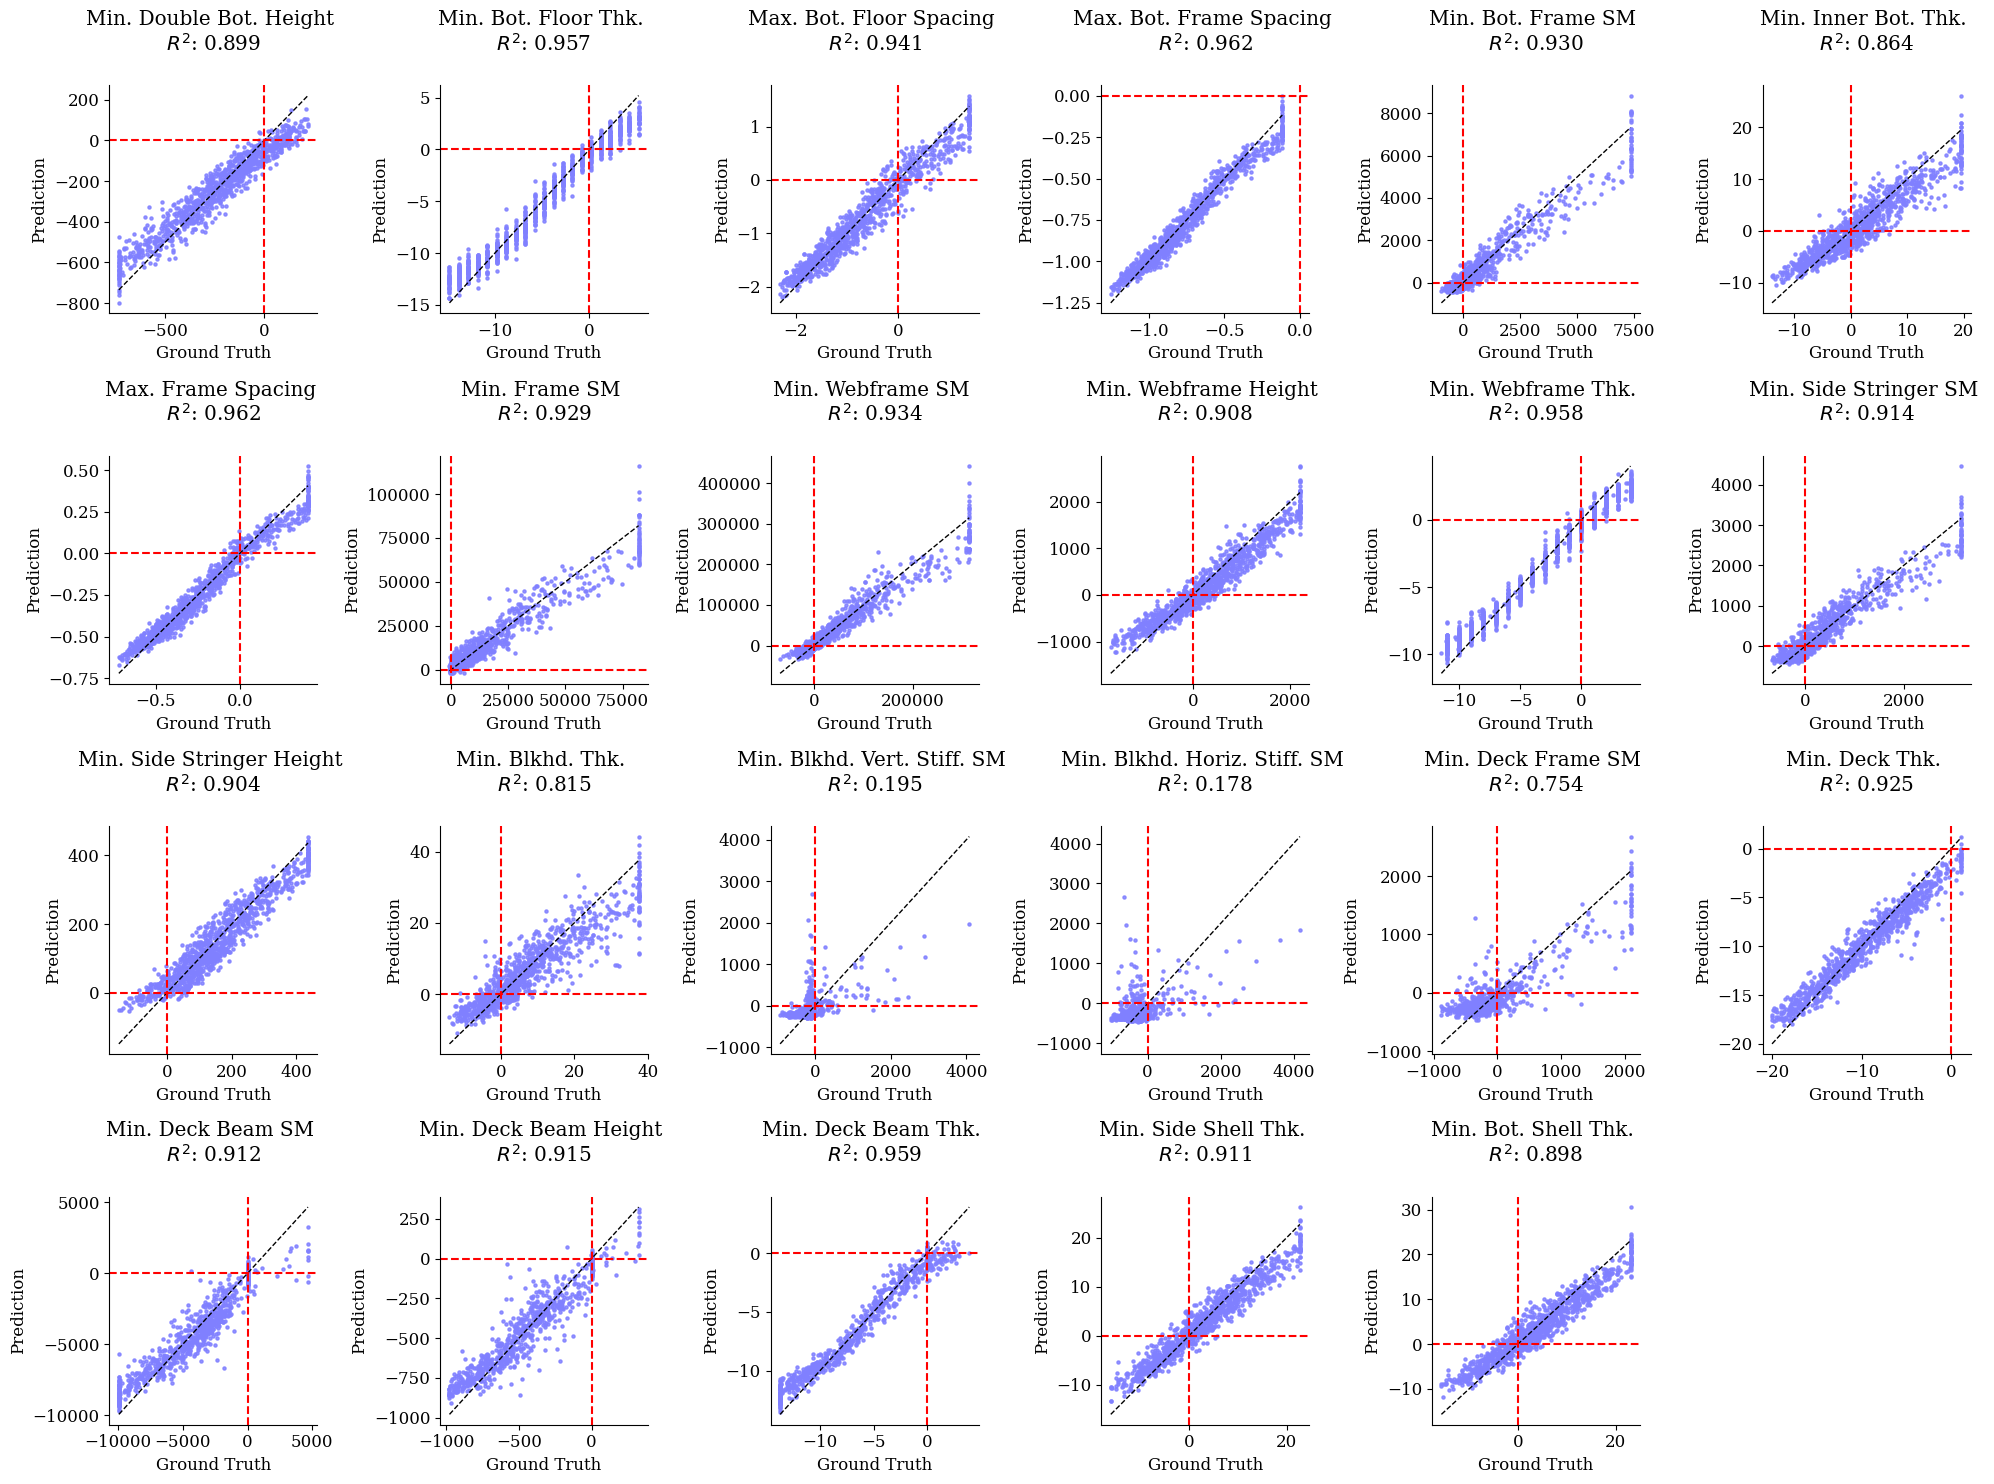

In [48]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12' 

colors = [[1,.5,.5], [.4,0.8,.4], [.5,.5,1]]

#Make three subplots that show the regression versus ground truth for the test set and put the R2 score in the title
fig, axs = plt.subplots(4, 6, figsize=(20, 15))

#plt.suptitle('Regression Accuracy For Surrogate Models')

axs = axs.flatten()

for i in range(len(Y[0])):
    axs[i].plot([min(Y_test_scaled_no_outliers[i]), max(Y_test_scaled_no_outliers[i])], [min(Y_test_scaled_no_outliers[i]), max(Y_test_scaled_no_outliers[i])], 'k--', alpha = 1, lw=1)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].scatter(Y_test_scaled_no_outliers[i], output_scaled_no_outliers[i], color=[0.5,0.5,1.0], marker='o', alpha=0.85, s=5, label = 'Constraint Predictions')
    # Add a vertical line at x=0 to show the boundary between satisfied and violated constraints
    axs[i].axvline(x=0, color='r', linestyle='--', label='Constraint Boundary')
    axs[i].axhline(y=0, color='r', linestyle='--', label='Prediction Constraint Boundary')
    axs[i].set_xlabel('Ground Truth')
    axs[i].set_ylabel('Prediction')
    axs[i].set_title(f'{constraint_names[i]} \n' + r'$R^2$: ' + f'{R2[i]:.3f}', pad=25)


# Place lengend info from axs[-2] where axs[-1] should be and turn off axs[-1]
#extract_legend = axs[-2].get_legend()
axs[-1].axis('off') # Turn off the last subplot if there are 23 constraints to make it look cleaner
#axs[-1].legend(*extract_legend.get_legend_handles_labels(), loc='center', frameon=False)

plt.tight_layout()

plt.savefig('./Figures/ABS_Cons_Reg.png', dpi=450)
plt.show()

In [7]:
# Lets extract the designs that satisfy all constraints and plot the distribution of their structural properties compared to the full dataset

con_vals = pd.read_csv(f"{path}/random_test_design_Constraint_Values.csv")
con_thresh = pd.read_csv(f"{path}/random_test_design_Constraint_Thresholds.csv")
con_diff = con_thresh - con_vals

#cons_diff = con_diff.drop(index=error_idx)
#reindex
#cons_diff = cons_diff.reset_index(drop=True)
# Get indices of designs that satisfy all constraints



# Get indices of designs that satisfy all constraints
feas_idx = con_diff.index[(con_diff <= 0).all(axis=1)].tolist()

#Remove error indices from feas_idx
feas_idx = [idx for idx in feas_idx if idx not in error_idx]

print(f"Number of feasible designs: {len(feas_idx)}")

print("Feasible indices:", feas_idx)





Number of feasible designs: 10
Feasible indices: [549, 853, 930, 1542, 2225, 2433, 2457, 2795, 3000, 4344]


# Now Let's Set Up Optimization #

## First step: set up NSGA_2 optimization class and support functions ##

In [26]:
opti_id = 'NSGA2_Opt_0'
n_var = len(X_data.columns)
pop_size = 25
n_obj = 2

n_constr = len(Y_zeros[0])

xl = np.amin(X_data.values, axis=0)
xu = np.amax(X_data.values, axis=0)

# We want to adjust the limits of L_3h, B, and D
LOA = 250 #for reference

# run_torch_nsga2_simple.py
# NSGA-II with default operators (no custom crossover/mutation/sampling).

from __future__ import annotations

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.termination import get_termination

# -----------------------------------------
# 1) Vectorized pymoo Problem (batch eval)
# -----------------------------------------
class Structure_Problem(Problem):
    def __init__(
        self,
        obj_model: nn.Module,
        cons_model: nn.Module,
        n_var: int,
        n_obj: int,
        n_ieq_constr: int,
        xl,
        xu,
        device: str = "cpu",
    ):
        super().__init__(n_var=n_var, n_obj=n_obj, n_ieq_constr=n_ieq_constr, xl=xl, xu=xu)
        self.obj_model = obj_model.to(device)
        self.cons_model = cons_model.to(device)
        self.device = device
        self.obj_model.eval()
        self.cons_model.eval()

    def _evaluate(self, X_c, out, *args, **kwargs):
        
        #X_c = clean_Struct_Params(X_c)
        #X_c = feature_engineer_X(X_c)
        #X_c = X_param_scaler.transform(X_c)

        X_t = torch.from_numpy(X_c).to(self.device).float()

        with torch.no_grad():
            F = self.obj_model(X_t).detach().cpu().numpy()
            F_t = np.array([F[:,0], -F[:,2]]).transpose() # We want to minimize weight and maximize bending moment, so we take the negative of the bending moment prediction for the second objective
            G_t = self.cons_model(X_t) - Y_zeros + 0.05 # We want to beat the constraint boundary by 0.05 to ensure we get feasible solutions
            
        
        out["F"] = F_t

        
        out["G"] = G_t.detach().cpu().numpy()

param_idx_bit = np.array([27,31,35,39,43,47,51,56,74,79,86,91,96, 100, 104,105,111,115,116]) #The indices of the parameters that are boolean values (T or C)
param_idx_cat = np.array([57,58,59]) #The indices of the parameters that are categorical values (Tanker, Container, Bulk Carrier)
param_idx_int = np.array([15,16,17,18,19,20,21,22,70, 75,82,87,92, 106]) #The indices of the parameters that are integers (number of stiffeners)

param_idx_plate_thicknesses = np.array([7,8,9,10,11,12,23,29,33,37,41,45,49,52,54,62,65,68,69,72,77,80,81,84,89,94,98,102,107,109,113])

param_idx_brackets = np.array([60,61,63,64]) #The indices of the parameters that are for the brackets -tanker and bulk carrier
param_idx_container = np.array([66,67,68,69,70,71,72,73,74,75,76,77,78,79]) #The indices of the parameters that are for the container step
param_idx_bulkcarrier = np.array([80,81,82,83,84,85,86,87,88,89,90,91]) #The indices of the parameters that are for the bulk carrier


def clean_Struct_Params(param_set):

    params = param_set.copy().astype(float) #Make sure we are working with floats to avoid issues with the int and bool conversions below

    for i in range(len(params)):
        
        params[i] = np.clip(params[i], xl,xu) #Clip all values to be between min and max values for each parameter
        
        params[i, param_idx_bit] = params[i, param_idx_bit] >= 0.5
        params[i, param_idx_int] = np.int32(params[i, param_idx_int]+0.5)
        params[i, param_idx_plate_thicknesses] = np.int32(params[i, param_idx_plate_thicknesses]+0.5)


        if params[i,6] < 1000.0*params[i,4]: #If the double bottom height is less than the bilge radius, set the bilge radius to Db height
                params[i,4] = params[i,6]/1000.0

                
        #Get argmax of categorical values to assign ship class
        ship_class = np.argmax(params[i,param_idx_cat])
        params[i,57:60] = 0 #Reset ship class values
        params[i,57 + ship_class] = 1 #Set the ship class to the argmax value


        #Check Categorical Values:
        if params[i,57] == 1: #Tanker
            params[i,param_idx_bulkcarrier] = 0
            params[i,param_idx_container] = 0
        elif params[i,58] == 1:
            params[i,param_idx_bulkcarrier] = 0
            params[i,param_idx_brackets] = 0
        elif params[i,59] == 1:
            params[i,param_idx_container] = 0
        
        #Check Inner Side wall Thickness
        if params[i,12] < 10.0:
            params[i,12] = 0
        else: 
            params[i,50] = 0 # If there is an inner side shell, no webframe flange cap. 
        #Chek Longitudinal Bulkhead
        if params[i,105] <= 0.5:
            params[i,105] = 0
            params[i,106:116] = 0.0
        elif params[i,106] <= 0.5:
            params[i,105:116] = 0.0
        else:
            params[i,105] = 1

        #check hatch openings
        if params[i,116] <= 0.5 or params[i,117] < 1e-2 or params[i,118] < 1e-2:
            params[i,116] = 0
            params[i,117:120] = 0.0


        else:
            params[i,116] = 1
    
    return params

In [27]:
opti_id = 'NSGA2_Opt_0'
n_var = len(X_data.columns)
pop_size = 25
n_obj = 2

n_constr = len(Y_zeros[0])

xl = np.amin(X_data.values[~error_idx], axis=0)
xu = np.amax(X_data.values[~error_idx], axis=0)

# We want to adjust the limits of L_3h, B, and D
LOA = 250 #for reference
#L_3h = 80
#B = LOA/7
#D = LOA/10

#xl[0] = L_3h*0.9
#xu[0] = L_3h*1.1

#xl[1] = B*0.9
#xu[1] = B*1.1

#xl[3] = D*0.9
#xu[3] = D*1.1

#print(xu-xl)


device = "cuda" if torch.cuda.is_available() else "cpu"


problem = Structure_Problem(
        obj_model = model_1,
        cons_model = model_cons,
        n_var=n_var,
        n_obj=n_obj,
        n_ieq_constr=n_constr,
        xl=xl,
        xu=xu,
        device=device  # set if you need to limit GPU memory
    )

# NSGA-II with default operators
algorithm = NSGA2(pop_size=pop_size)

res = minimize(
        problem,
        algorithm,
        get_termination("n_gen", 100),
        seed=1,
        verbose=False,
    )



#Save the results to a csv file
#First make a folder for optimization 
opt_path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Optimization_Results'
if not os.path.exists(opt_path):
    os.makedirs(opt_path)

'''
#Convert results to a dataframe and save
opt_results = pd.DataFrame(res.pop.get('X'), columns=X_data.columns)
opt_results.to_csv(f"{opt_path}/{opti_id}_X_Results.csv", index=False)

# First we need to scale the results
F = np.zeros((len(res.pop.get('F')), 3))
F[:,0] = res.pop.get('F')[:,0] # Structural Weight
F[:,1] = -res.pop.get('F')[:,1] # Max Bending Moment (negated back to original scale)
#Convert back to original scale using the same scalers used for training the surrogate model
F = Y_scaler_obj.inverse_transform(F)

opt_results_F = pd.DataFrame(F[:,[0,2]], columns=['Structural Weight [kg]', 'Max Bending Moment [Nm]'])
opt_results_F.to_csv(f"{opt_path}/{opti_id}_F_Results.csv", index=False) 

#Convert the constraint violations back to original scale and save
G = res.pop.get('G') + Y_zeros.cpu().numpy() - 0.05 # Add back the 0.05 that we subtracted in the constraint function
G = Y_scaler0.inverse_transform(Y_scaler1.inverse_transform(G))
opt_results_G = pd.DataFrame(G, columns=y_labels)
opt_results_G.to_csv(f"{opt_path}/{opti_id}_G_Results.csv", index=False)

'''


    




'\n#Convert results to a dataframe and save\nopt_results = pd.DataFrame(res.pop.get(\'X\'), columns=X_data.columns)\nopt_results.to_csv(f"{opt_path}/{opti_id}_X_Results.csv", index=False)\n\n# First we need to scale the results\nF = np.zeros((len(res.pop.get(\'F\')), 3))\nF[:,0] = res.pop.get(\'F\')[:,0] # Structural Weight\nF[:,1] = -res.pop.get(\'F\')[:,1] # Max Bending Moment (negated back to original scale)\n#Convert back to original scale using the same scalers used for training the surrogate model\nF = Y_scaler_obj.inverse_transform(F)\n\nopt_results_F = pd.DataFrame(F[:,[0,2]], columns=[\'Structural Weight [kg]\', \'Max Bending Moment [Nm]\'])\nopt_results_F.to_csv(f"{opt_path}/{opti_id}_F_Results.csv", index=False) \n\n#Convert the constraint violations back to original scale and save\nG = res.pop.get(\'G\') + Y_zeros.cpu().numpy() - 0.05 # Add back the 0.05 that we subtracted in the constraint function\nG = Y_scaler0.inverse_transform(Y_scaler1.inverse_transform(G))\nopt_resul

## Let's Try Stochastic Gradient Descent ##

Let's optimize a structure for Weight and Bending Stress

In [28]:
#sigma = 0.001
sigma = 0.01
alpha = 0.1

XL = torch.from_numpy(X_param_scaler.transform(xl.reshape(1,-1))).float().to(device)
XU = torch.from_numpy(X_param_scaler.transform(xu.reshape(1,-1))).float().to(device)


xlen = len(X_data.columns)

def optimize_step(X_t, sigma=sigma, alpha=alpha):
    #X_c = clean_Struct_Params(X_c)

    #X_c = feature_engineer_X(X_c)
    #X_c = X_param_scaler.transform(X_c)

    #X_t = torch.from_numpy(X_c).to(device).float()

    # Weight the different objectives from 0 to 1 linspace
    #weights = torch.tensor(np.linspace(0, 1, len(X_t))).float().to(device)

    with torch.enable_grad():
        
        X_t.requires_grad_(True)
        F = model_1(X_t)
        G = model_cons(X_t) - Y_zeros+0.3 # We want to beat the constraint boundary by 0.1 to ensure we get feasible solutions

        F_step = torch.sum(F[:,0]) - sum(F[:,2]) # We want to minimize weight and maximize bending moment, so we take the negative of the bending moment prediction for the second objective 
        
        #Try relu weighting
        G_step = torch.sum(nn.LeakyReLU()(G))# We only want to prioritize satisfying the constraints that are violated, so we take the leaky relu of the constraint violations to only get positive values for violated constraints

        #G_step = torch.sum(G)
        '''
        if G.any() > 0: # If any constraints are violated, we want to prioritize satisfying the constraints over optimizing the objectives
            step = -0.2*F_step - G_step 
        else:
            step = -F_step + 0.2*G_step

        '''
        step = -G_step-0.2*F_step
        #step = -G_step
        step.sum().backward()

        #print("Step:", step.item())
        #print(X_t.grad)
        
        X_out = X_t + alpha*X_t.grad + sigma*torch.randn_like(X_t)

    X_out = X_out.detach()

    #now inverse transform the scaled X_s back to the original scale and only return original parameters (not the feature engineered ones)
    #X_s = X_param_scaler.inverse_transform(X_s)
    
    #X_s = X_s[:, 0:xlen] # Only return the original parameters

    return X_out


def Stochastic_Gradient_Langevin_Dynamics(X_init, seed_interp, num_steps=100, sigma=sigma, alpha=alpha):
    X_sgld = X_init.copy()

    X_sgld = X_param_scaler.transform(X_sgld)

    if seed_interp:
        #Randomly interpolate between the initial population
        print("Using seed interpolation for optimization")
        A = np.random.choice(len(X_sgld), size=(len(X_sgld), 2), replace=True)
        b = np.random.rand(len(X_sgld), 1)
        X_sgld = X_sgld[A[:,0]]*b + X_sgld[A[:,1]]*(1-b)
        
    X_sgld = torch.from_numpy(X_sgld).to(device).float()

    for i in tqdm(range(num_steps)):
        X_sgld = optimize_step(X_sgld, sigma=sigma, alpha=alpha)
        X_sgld = torch.clip(X_sgld, XL, XU) # Clip the values to the original bounds

    X_sgld = X_sgld.detach().cpu().numpy()
    X_sgld = X_param_scaler.inverse_transform(X_sgld)
    X_sgld = clean_Struct_Params(X_sgld)
    return X_sgld


## Now let's run a gradient descent optimization and save the results

In [8]:
#initialize by grabbing random members of the dataset 
opt_path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Optimization_Results'
opti_id = 'SGD_Opt_1'
pop_size = 100

X_data = pd.read_csv(path + '/random_test_design_Parameters_All.csv')

A = np.random.choice(feas_idx, size=pop_size, replace=True)

print("Initial designs for SGD:", A)

X_init = X_data.values[A,:].astype(float)
#X_init = clean_Struct_Params(X_init)


X_opt = Stochastic_Gradient_Langevin_Dynamics(X_init, seed_interp=True, num_steps=10, sigma=sigma, alpha=alpha)

F_opt = model_1(torch.from_numpy(X_param_scaler.transform(X_opt)).to(device).float()).detach().cpu().numpy()
F_opt = Y_scaler_obj.inverse_transform(F_opt)

G_opt = model_cons(torch.from_numpy(X_param_scaler.transform(X_opt)).to(device).float()).detach().cpu().numpy()
G_opt = Y_scaler0.inverse_transform(Y_scaler1.inverse_transform(G_opt))

#Save the results to a csv file
opt_results = pd.DataFrame(X_opt, columns=X_data.columns)
opt_results.to_csv(f"{opt_path}/{opti_id}_X_Results.csv", index=False)

opt_results_F = pd.DataFrame(F_opt[:,[0,2]], columns=['Structural Weight [kg]', 'Max Bending Moment [Nm]'])
opt_results_F.to_csv(f"{opt_path}/{opti_id}_F_Results.csv", index=False)

opt_results_G = pd.DataFrame(G_opt, columns=y_labels)
opt_results_G.to_csv(f"{opt_path}/{opti_id}_G_Results.csv", index=False)

Initial designs for SGD: [2795  549  853 3000 2457 1542 2433  549 2433  930 4344  930 2225 4344
 1542 2433 2795 2225 1542 3000  853 2225 4344 2457  930 2457 2795 3000
 4344 2433 2795 2457 1542 2457  549 2433 3000 1542 2795  930  853 3000
 2433  853  930 2225 2225 4344 2433 2225 2225 1542  549 2433 3000 4344
  853  853 2433  549 1542 2795  930 2795 3000  549 1542  549 4344  930
 2457 4344  853 2457 3000 2457  549  853 2457 1542  549  853 2225  853
 4344 2457  549 3000 2225 2795  549 4344 1542 2225 2795  853 1542  549
 1542 1542]


NameError: name 'Stochastic_Gradient_Langevin_Dynamics' is not defined

# Now Let's Reevaluate the Optimized Structures #

Run Rhino Script for evaluating the designs:

NSGA 2
notes: Population of 1000 for 1500 generations took 152 seconds
Pop 1000 for 100 gens took 10.5 seconds

Pop 100 gen 200 t =1.5 sec


SGD
25 samples for 10k steps 11 sec


In [9]:
opti_id = 'SGD_Opt_1_design'

opt_file_path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Optimization_Results'

num_samples = 100

#merge_data(file_path, np.array(['0_24']), opti_id) #999', '4000_4999', '5000_5006']))

format_training_data(opt_file_path, opti_id, num_samples)




    

No error indices found for SGD_Opt_1_design.


  7%|▋         | 7/100 [00:00<00:01, 62.06it/s]

{'Trans_Bulkheads': 14.030456657268493, 'Webframes': 1.558939629581948, 'Frames': 0.3897349051532275, 'Deck_Girders': 3.552713678800501e-15, 'Deck_Stringers': 1.7763568394002505e-15, 'Bottom_Girders': 1.8334652937637117, 'Bottom_Stringers': 0.3055775492007598, 'Side_Stringers': 0.6424192846019943, 'Trans_Bulkhead_Horizontal_Stiffeners': 1.5543122344752192e-15, 'Trans_Bulkhead_Vertical_Stiffeners': 0.6111550984015195}
{'Trans_Bulkhead_Thickness': 19.0, 'Bottom_Floor_Thickness': 28.0, 'Webframe_height': 1.5742064208984374, 'Webframe_thickness': 19.0, 'Webframe_flange_width': 0.0, 'N_frames': 3, 'Frame_height': 0.2186969451904296, 'Frame_thickness': 7.0, 'Frame_flange_width': 0.1434622802734375, 'Deck_Beam_height': 0.563356689453125, 'Deck_Beam_thickness': 14.0, 'Deck_Beam_flange_width': 0.3088735656738281, 'Deck_frame_height': 0.1708425598144531, 'Deck_frame_thickness': 9.0, 'Deck_frame_flange_width': 0.0284310054779052, 'Side_Stringer_height': 0.2216182556152344, 'Side_Stringer_thicknes

100%|██████████| 100/100 [00:01<00:00, 84.98it/s]
/var/folders/6c/7y2jzhfd6t3750c02xt1gxl00000gn/T/ipykernel_32987/4057899104.py:115: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  constraint_thresholds = constraint_thresholds.fillna(0.0)
/var/folders/6c/7y2jzhfd6t3750c02xt1gxl00000gn/T/ipykernel_32987/4057899104.py:116: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  constraint_evals = constraint_evals.fillna(0.0)


## Let's plot three things: 

1) NN Predictions vs Ground Truth for Optimized Results
2) Range of Objective Function Values for Optimized vs Dataset
3) Range of Constraints for Optimized vs Dataset

In [10]:
# First plot Predicted vs Ground Truth for the test set for the surrogate model with R2 score in the title

#Load X Data info: 
path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'
error_idx = np.loadtxt(f"{path}/random_test_design_error_idx_All.csv", delimiter=',', dtype=int)
try:
    error_idx_opt = np.loadtxt(f"{opt_file_path}/{opti_id}_error_idx_All.csv", delimiter=',', dtype=int)
except:
    error_idx_opt = np.array([])
#Load y Data:
Y_data = pd.read_csv(path + '/random_test_design_Structural_Properties.csv')
Y_data_opt = pd.read_csv(opt_file_path + f'/{opti_id}_Structural_Properties.csv')

#Y_data = Y_data.drop(index=error_idx)
#Y_data_opt = Y_data_opt.dropna()


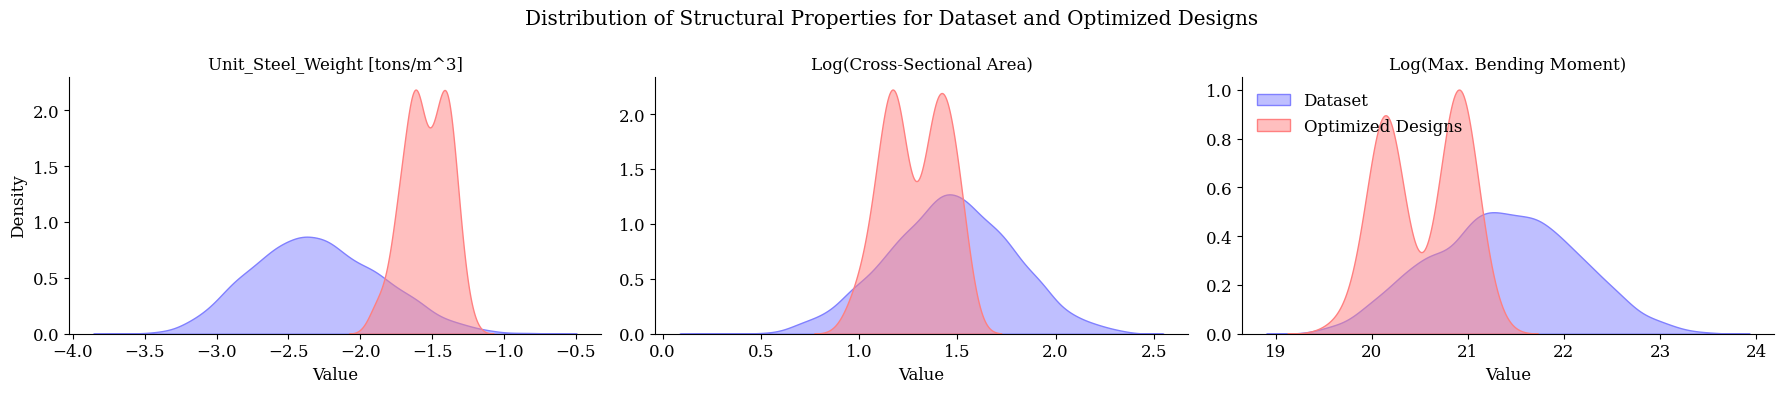

In [11]:
#Let's plot a kde of each of the Y_data columns

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12' 

colors = [[1,.5,.5], 
          [.4,.8,.4], 
          [.5,.5,1],
          [1,.5,.5],
          [.4,.8,.4],
          [.5,.5,1]]

idx = [2, 6, 11]  # Indices of the columns to plot
columns_to_plot = df_columns[idx]

Y_data_subset = Y_data.melt(id_vars=None, value_vars=columns_to_plot, var_name='Structural Property', value_name='Val')
Y_data_subset['Val'] = np.log(Y_data_subset['Val'])

Y_data_opt_subset = Y_data_opt.melt(id_vars=None, value_vars=columns_to_plot, var_name='Structural Property', value_name='Val')
Y_data_opt_subset['Val'] = np.log(Y_data_opt_subset['Val'])


#Rename the columns in Y_data_subset for clarity
Y_data_subset['Structural Property'] = Y_data_subset['Structural Property'].replace({
    r'Unit_Steel_Weight [tons/$m^3$]': 'Log(Unit Steel Weight)',
    r'Cross_Sectional_Area [m^2]': 'Log(Cross-Sectional Area)',
     'Max_Bending_Moment [Nm]': r'Log(Max. Bending Moment)'
})

Y_data_opt_subset['Structural Property'] = Y_data_opt_subset['Structural Property'].replace({
    r'Unit_Steel_Weight [tons/$m^3$]': 'Log(Unit Steel Weight)',
    r'Cross_Sectional_Area [m^2]': 'Log(Cross-Sectional Area)',
     'Max_Bending_Moment [Nm]': r'Log(Max. Bending Moment)'
})




#now make a kde plot in. facetgrid. one row is 'Value' and the other row is 'Log Value'
g = sns.FacetGrid(Y_data_subset, col='Structural Property', sharex=False, sharey=False, height=4, aspect=1.5, col_wrap=3, legend_out=True)

for ax, var in zip(g.axes.flatten(), Y_data_subset["Structural Property"].unique()):
    sns.kdeplot(
        data=Y_data_subset[Y_data_subset["Structural Property"] == var],
        x="Val",
        fill=True,
        ax=ax,
        color=colors[2],
        alpha=0.5,
        label='Dataset'
    )
    sns.kdeplot(
        data=Y_data_opt_subset[Y_data_opt_subset["Structural Property"] == var],
        x="Val",
        fill=True,
        ax=ax,
        color=colors[0],
        alpha=0.5,
        label='Optimized Designs'
    )
    #mu, std = Y_data_subset[Y_data_subset["Structural Property"] == var]["Val"].mean(), Y_data_subset[Y_data_subset["Structural Property"] == var]["Val"].std()
    #x = np.linspace(mu - 3*std, mu + 3*std, 100)
    #ax.plot(x, norm.pdf(x,mu,std), color=(0.3,0.3,0.3), linestyle='--', label=r'Normal Dist. Around $\mu, \sig$ of Data')

g.set_axis_labels("Value", "Density")
g.set_titles("{col_name}")
#lengend should be bottom center and no bounding box, do not anchor to the axes, but to the figure, and have two columns
ax.legend(['Dataset', 'Optimized Designs'], frameon=False, loc='upper left')
plt.subplots_adjust(bottom=0.2)
#center the title on ax1
plt.suptitle('Distribution of Structural Properties for Dataset and Optimized Designs')
plt.tight_layout()
plt.show()

## Now let's look at constraints ##

In [12]:
# First lets load the constraint thresholds and values and plot the constraint violations for the test set.
constraint_thresholds = pd.read_csv(f"{path}/random_test_design_Constraint_Thresholds.csv")
constraint_evals = pd.read_csv(f"{path}/random_test_design_Constraint_Values.csv")

#constraint_diff = -(constraint_thresholds - constraint_evals)/(constraint_thresholds+1e-2) # Goal is to get negative
constraint_diff = constraint_thresholds - constraint_evals # Goal is to get negative

#constraint_diff = constraint_diff.drop(index=error_idx)

#clip to median+/- 2 sigma for each category
med = constraint_diff.median(axis=0)

sigma = constraint_diff.std(axis=0)
print(sigma.shape)

constraint_diff = constraint_diff.clip(med - 2*sigma, med + 2*sigma, axis=1)
print(constraint_diff.shape)

#first melt each dataframe to have columns for 'constraint_name', a column for index and a column for 'Value'
constraint_thresholds_melted = constraint_thresholds.melt(id_vars=None, var_name='Constraint', value_name='Value')
constraint_evals_melted = constraint_evals.melt(id_vars=None, var_name='Constraint', value_name='Value')

constraint_diff_melted = constraint_diff.melt(id_vars=None, var_name='Constraint', value_name='Value')


constraints_thresholds_opt = pd.read_csv(f"{opt_file_path}/{opti_id}_Constraint_Thresholds.csv")
constraints_evals_opt = pd.read_csv(f"{opt_file_path}/{opti_id}_Constraint_Values.csv")

constraint_diff_opt = constraints_thresholds_opt - constraints_evals_opt

constraint_diff_opt = constraint_diff_opt.drop(index=error_idx_opt)

med_opt = constraint_diff_opt.median(axis=0)
sigma_opt = constraint_diff_opt.std(axis=0)
constraint_diff_opt = constraint_diff_opt.clip(med_opt - 2*sigma_opt, med_opt + 2*sigma_opt, axis=1)

constraint_diff_opt_melted = constraint_diff_opt.melt(id_vars=None, var_name='Constraint', value_name='Value')





(23,)
(5050, 23)


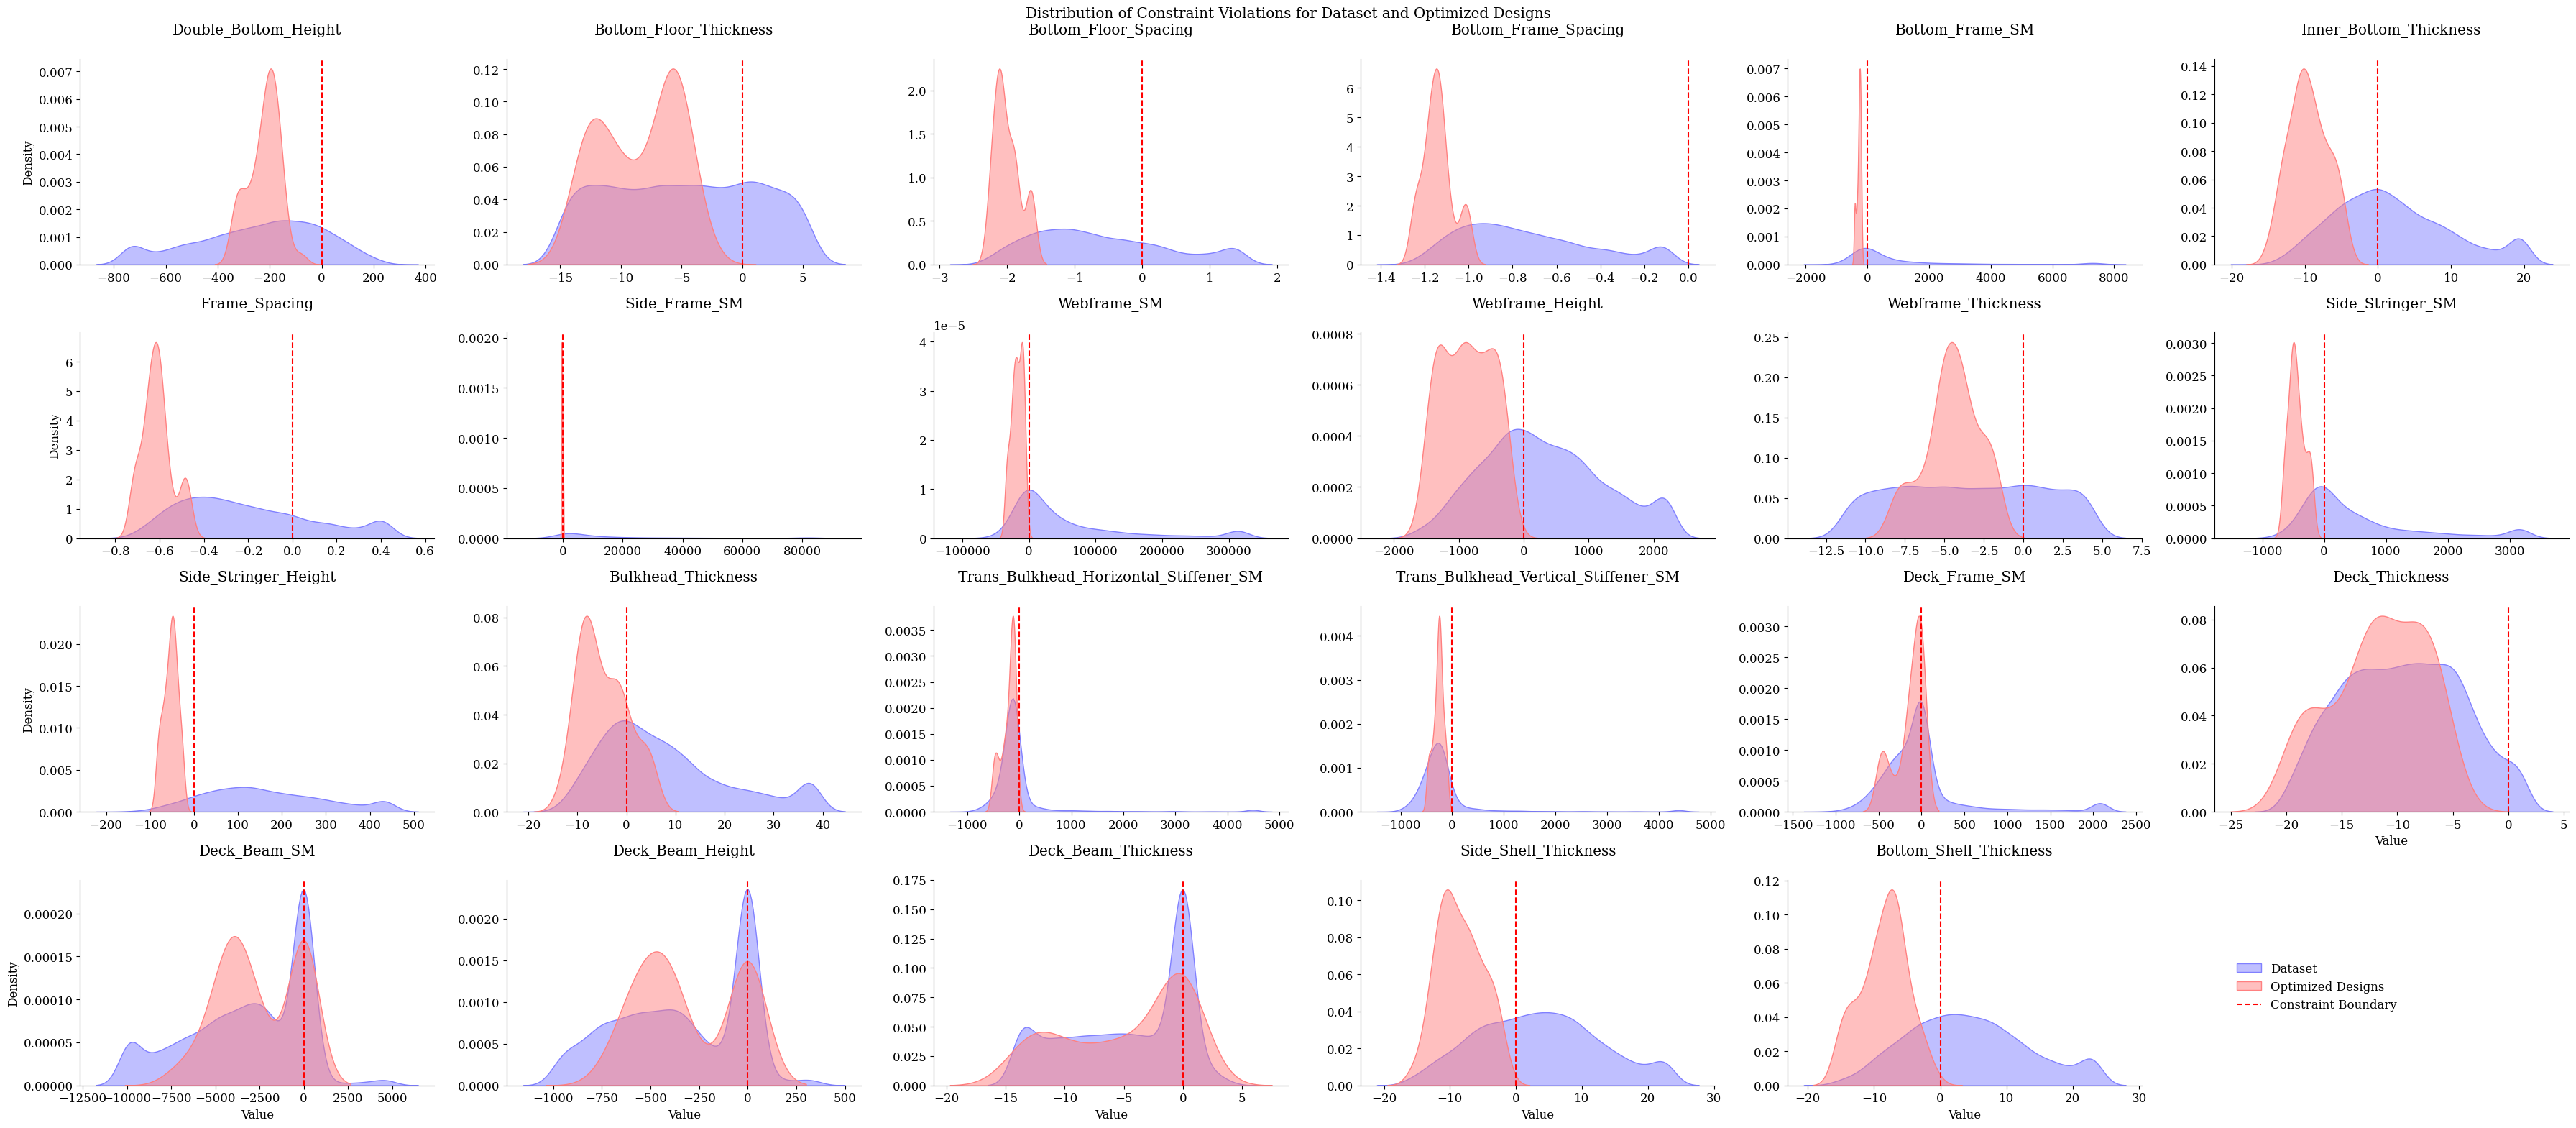

In [13]:
# Now let's plot the differene 

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12'

g = sns.FacetGrid(constraint_diff_melted, col='Constraint', sharex=False, sharey=False, height=4, aspect=1.5, col_wrap=6)

for ax, var in zip(g.axes.flatten(),constraint_diff_melted['Constraint'].unique()):
    sns.kdeplot(
        data=constraint_diff_melted[constraint_diff_melted["Constraint"] == var],
        x="Value",
        fill=True,
        ax=ax,
        color=colors[2],
        alpha=0.5
    )

    sns.kdeplot(
        data=constraint_diff_opt_melted[constraint_diff_opt_melted["Constraint"] == var],
        x="Value",
        fill=True,
        ax=ax,
        color=colors[0],
        alpha=0.5
    )

    #add vertical line at x=0 to show the boundary between satisfied and violated constraints
    ax.axvline(x=0, color='r', linestyle='--', label='Constraint Boundary')
    

#Get percent of samples that satisfy each constraint and put it in the title of each subplot
for ax, var in zip(g.axes.flatten(),constraint_diff_melted['Constraint'].unique()):
    total_samples = len(constraint_diff_melted[constraint_diff_melted["Constraint"] == var])
    satisfied_samples = len(constraint_diff_melted[(constraint_diff_melted["Constraint"] == var) & (constraint_diff_melted["Value"] <= 0)])
    fease_rate = satisfied_samples / total_samples
    #ax.set_title(f'{var}, ' + f'Fease. Rate: {fease_rate:.4}', pad=25)
    ax.set_title(f'{var}', pad=25)

g.set_axis_labels("Value", "Density")
#g.set_titles("{col_name}")
plt.suptitle('Distribution of Constraint Violations for Dataset and Optimized Designs')
plt.tight_layout()
ax.legend(['Dataset', 'Optimized Designs', 'Constraint Boundary'], frameon=False, loc='upper right', bbox_to_anchor=(1.75, 0.65))
plt.show()

Number of feasible designs: 71 out of 100 total optimized designs


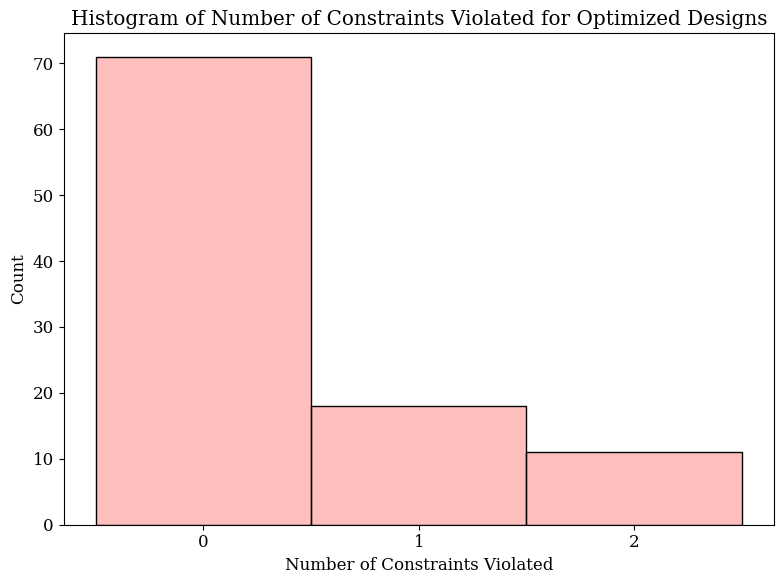

In [14]:
# Let's see which designs satisfy all constraints by looking at the constraint_diff_opt dataframe and counting how many rows have all values <= 0 (meaning they satisfy all constraints)
num_feasible_designs = len(constraint_diff_opt[(constraint_diff_opt <= 0).all(axis=1)])
print(f'Number of feasible designs: {num_feasible_designs} out of {len(constraint_diff_opt)} total optimized designs')

# Lets plot histogram of number of constraints violated for the optimized designs

opt_hist = (constraint_diff_opt > 0).sum(axis=1)

plt.figure(figsize=(8,6))
sns.histplot(opt_hist, bins=np.arange(-0.5, opt_hist.max()+1.5), color=colors[0], alpha=0.5)
plt.xlabel('Number of Constraints Violated')
#Show x ticks for each integer value of number of constraints violated
plt.xticks(np.arange(0, opt_hist.max()+1))
plt.ylabel('Count')
plt.title('Histogram of Number of Constraints Violated for Optimized Designs')
plt.tight_layout()
plt.show()


## Let's extract some stats about the designs ##

In [17]:
# Get the lightest, heaviest, and stiffest structures
path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'
error_idx = np.loadtxt(f"{path}/random_test_design_error_idx_All.csv", delimiter=',', dtype=int)
print("Error indices:", error_idx)

X_data = pd.read_csv(path + '/random_test_design_Parameters_All.csv')
#X_data = X_data.drop(index=error_idx)
#print(len(X_data))
# Reset Index after dropping rows
#X_data = X_data.reset_index(drop=True)

X_optimized = pd.read_csv(f"{opt_file_path}/SGD_Opt_1_X_Results_Updated.csv")

Y_optimized = pd.read_csv(f"{opt_file_path}/SGD_Opt_1_design_Structural_Properties.csv")

Y_data = pd.read_csv(path + '/random_test_design_Structural_Properties.csv')

x_class_idx = []
x_class_idx.append(X_data[X_data['cat container'] == 1].index)
x_class_idx.append(X_data[X_data['cat tanker'] == 1].index)
x_class_idx.append(X_data[X_data['cat bulkcarrier'] == 1].index)

stiffest_idx = Y_data['Max_Bending_Moment [Nm]'].nlargest(25).index.tolist()
lightest_idx = Y_data['Unit_Steel_Weight [tons/m^3]'].nsmallest(25).index.tolist()

print("Stiffest indices:", stiffest_idx)
print("Lightest indices:", lightest_idx)

#max_I22_idx = Y_data['I_22 [m^4]'].nlargest(25).index.tolist()
#print("Max I22 indices:", max_I22_idx)

# Get idx of stiffest and lightest designs that also satisfy all constraints
Y_fease = Y_data.iloc[feas_idx]

#print(Y_fease)

Y_fease_stiff_idx = Y_fease['Max_Bending_Moment [Nm]'].nlargest(25).index.tolist()
Y_fease_light_idx = Y_fease['Unit_Steel_Weight [tons/m^3]'].nsmallest(25).index.tolist()

print("Feasible Stiffest indices:", Y_fease_stiff_idx)
print("Feasible Lightest indices:", Y_fease_light_idx)

# Get feasible optimized designs that are the stiffest and lightest
opt_fease = constraint_diff_opt[(constraint_diff_opt <= 0).all(axis=1)].index


print(opt_fease)



Error indices: [ 562  683 1185 1335 1979 2239 2292 2435 2699 2975 3106 3349 3380 3402
 3526 3545 3937 4075 4077 4129 4203 4505 4705 4780 4922 4974]
Stiffest indices: [2060, 1193, 2805, 1261, 712, 510, 2924, 4828, 1073, 790, 4338, 3329, 2595, 1329, 4647, 2322, 3710, 926, 669, 311, 4638, 4311, 4706, 4111, 3443]
Lightest indices: [554, 4618, 3718, 2209, 3716, 1890, 3824, 3566, 44, 740, 1861, 2539, 4815, 3893, 268, 3329, 3638, 4988, 5041, 2989, 4828, 3808, 1154, 3885, 3300]
Feasible Stiffest indices: [2457, 2433, 4344, 2225, 853, 3000, 549, 930, 1542, 2795]
Feasible Lightest indices: [3000, 930, 549, 2225, 2457, 1542, 853, 2433, 2795, 4344]
Index([ 0,  3,  4,  6,  8,  9, 11, 12, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24,
       25, 27, 29, 30, 32, 34, 35, 36, 39, 40, 42, 43, 45, 46, 48, 49, 51, 52,
       53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 73, 74, 75, 76,
       77, 78, 79, 81, 83, 84, 85, 87, 89, 90, 91, 94, 95, 96, 97, 98, 99],
      dtype='int64')


In [18]:
#Number of each class

print("Number of Container Ships:", (X_data['cat container'] == 1).sum())
print("Number of Tankers:", (X_data['cat tanker'] == 1).sum())
print("Number of Bulkcarriers:", (X_data['cat bulkcarrier'] == 1).sum())



Number of Container Ships: 1583
Number of Tankers: 1698
Number of Bulkcarriers: 1743


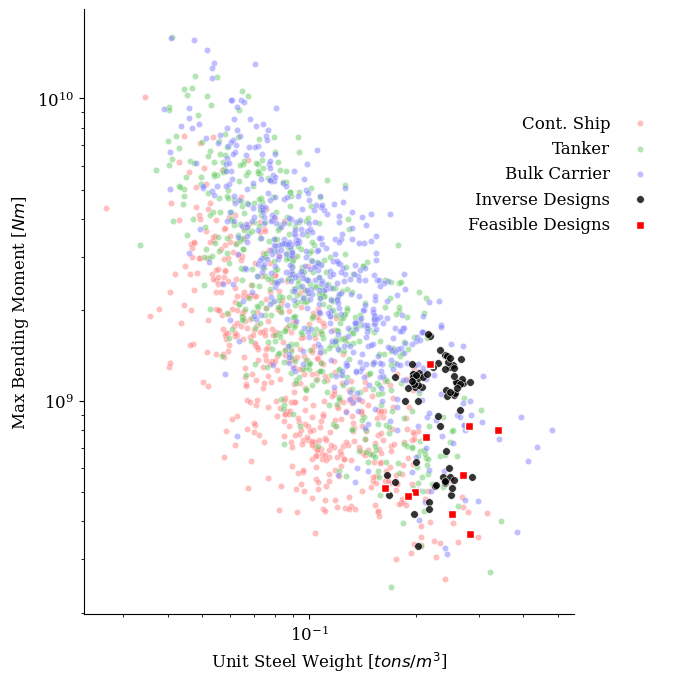

In [19]:
#now make plot of weight and stiffness y values make sure stiff is signed correct
#separate by class, feasibility, and high performing designs
# Remake tsne and add the feasible designs in a different color
feas_color = [1,0,0]
num_plot = 512
Y1 = 'Unit_Steel_Weight [tons/m^3]'
#Y1 = 'Steel_Weight [tons]'
Y2 = 'Max_Bending_Moment [Nm]'

plt.figure(figsize=(7,7))
sns.scatterplot(x=Y_data[Y1][x_class_idx[0][0:num_plot]], y=Y_data[Y2][x_class_idx[0][0:num_plot]], s = 20, color=colors[0], alpha=0.5, label= 'Cont. Ship')
sns.scatterplot(x=Y_data[Y1][x_class_idx[1][0:num_plot]], y=Y_data[Y2][x_class_idx[1][0:num_plot]], s=20, color=colors[1], alpha=0.5, label= 'Tanker')
sns.scatterplot(x=Y_data[Y1][x_class_idx[2][0:num_plot]], y=Y_data[Y2][x_class_idx[2][0:num_plot]], s=20, color=colors[2], alpha=0.5, label= 'Bulk Carrier')

#sns.scatterplot(x=Y_data[Y1][stiffest_idx], y=Y_data[Y2][stiffest_idx], linewidth = 1, marker='X', s=50, color=(0,0,1), alpha=1.0, label= 'Stiffest Designs')
#sns.scatterplot(x=Y_data[Y1][lightest_idx], y=Y_data[Y2][lightest_idx], linewidth = 1, marker='D', s=30, color=(0,0,1), alpha=1.0, label= 'Lightest Designs')

sns.scatterplot(x=Y_optimized[Y1][opt_fease], y=Y_optimized[Y2][opt_fease], color='k', alpha=0.8, label='Inverse Designs', marker='o', s=30)
sns.scatterplot(x=Y_data[Y1][feas_idx], y=Y_data[Y2][feas_idx], linewidth = 1, marker='s', s=30, color=feas_color, alpha=1.0, label= 'Feasible Designs')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)   
# Make x and y on a log scale
plt.xscale('log')
plt.yscale('log') 
#plt.title('Structural Performance of Ship Designs')
plt.xlabel(r'Unit Steel Weight [$tons/m^3$]')
plt.ylabel(r'Max Bending Moment [$Nm$]')
plt.legend(loc='upper right', frameon=False,bbox_to_anchor=(1.2, 0.85), markerfirst=False)
plt.tight_layout()
plt.show()


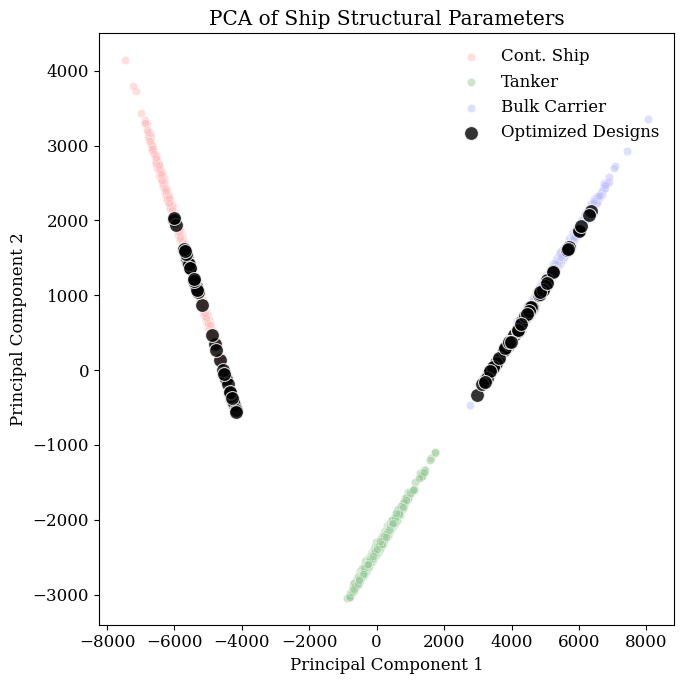

In [40]:
# Now let's make PCA and TSNE plots of the parameters and color by ship class

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


colors = [[1,.75,.75], [.6,0.8,.6], [.75,.75,1]]
# Assign colors based on ship class
ship_class_colors = np.zeros((len(X_data), 3))




#idx_no_error = [idx for idx in range(len(X_data)) if idx not in error_idx]

# FIRST PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_data.values)

X_opt_pca = pca.transform(X_optimized.values)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12'

plt.figure(figsize=(7,7))

sns.scatterplot(x=X_pca[x_class_idx[0],0], y=X_pca[x_class_idx[0],1], color=colors[0], alpha=0.5, label= 'Cont. Ship')
sns.scatterplot(x=X_pca[x_class_idx[1],0], y=X_pca[x_class_idx[1],1], color=colors[1], alpha=0.5, label= 'Tanker')
sns.scatterplot(x=X_pca[x_class_idx[2],0], y=X_pca[x_class_idx[2],1], color=colors[2], alpha=0.5, label= 'Bulk Carrier')
sns.scatterplot(x=X_opt_pca[:,0], y=X_opt_pca[:,1], color='k', alpha=0.8, label='Optimized Designs', marker='o', s=100)

plt.title('PCA of Ship Structural Parameters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper right', frameon=False)
plt.tight_layout()

plt.show()


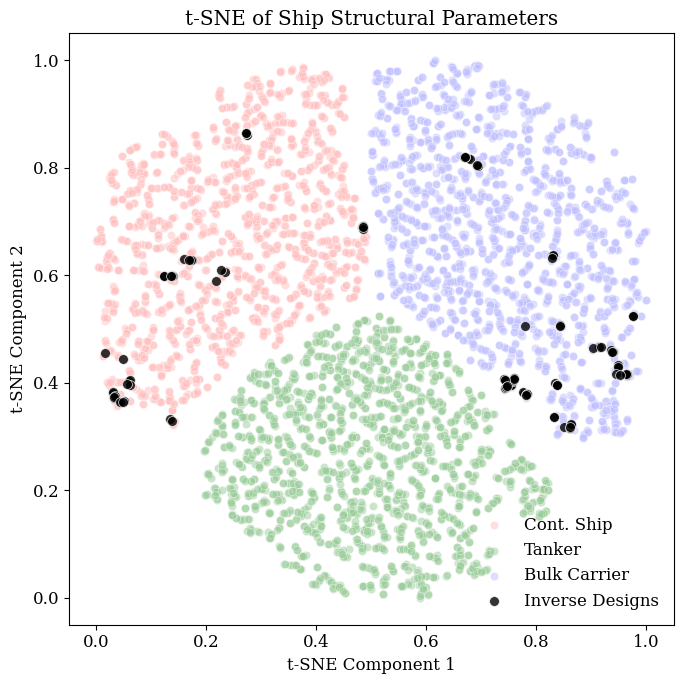

In [42]:
# Now TSNE
#merge x and x_opt for tsne so that they are on the same scale
X_tsne = np.concatenate((X_data.values, X_optimized.values), axis=0)
tsne = TSNE(n_components=2, perplexity=5, max_iter=1000)
X_tsne = tsne.fit_transform(X_tsne)


#Scale TSNE components to be between 0 and 1 for better visualization
X_tsne = (X_tsne - X_tsne.min(axis=0)) / (X_tsne.max(axis=0) - X_tsne.min(axis=0))

plt.figure(figsize=(7,7))
sns.scatterplot(x=X_tsne[x_class_idx[0],0], y=X_tsne[x_class_idx[0],1], color=colors[0], alpha=0.5, label= 'Cont. Ship')
sns.scatterplot(x=X_tsne[x_class_idx[1],0], y=X_tsne[x_class_idx[1],1], color=colors[1], alpha=0.5, label= 'Tanker')
sns.scatterplot(x=X_tsne[x_class_idx[2],0], y=X_tsne[x_class_idx[2],1], color=colors[2], alpha=0.5, label= 'Bulk Carrier')
sns.scatterplot(x=X_tsne[len(X_data):,0], y=X_tsne[len(X_data):,1], color='k', alpha=0.8, label='Inverse Designs', marker='o', s=50)
plt.title('t-SNE of Ship Structural Parameters')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

Stiffest indices: [2055, 1190, 2796, 1258, 710, 510, 2915, 4804, 1071, 788, 4317, 3318, 2587, 1326, 4625, 2315, 3694, 924, 668, 311, 4616, 4290, 4683, 4092, 3429]
Lightest indices: [554, 4596, 3702, 2204, 3700, 1886, 3808, 3550, 44, 738, 1857, 2531, 4791, 3877, 268, 3318, 3622, 4962, 5015, 2979, 4804, 3792, 1152, 3869, 3289]
Feasible Stiffest indices: [2795, 930, 2225, 2457, 3000, 4344, 1542, 853, 2433, 549]
Feasible Lightest indices: [2225, 3000, 930, 4344, 1542, 853, 2457, 2795, 2433, 549]


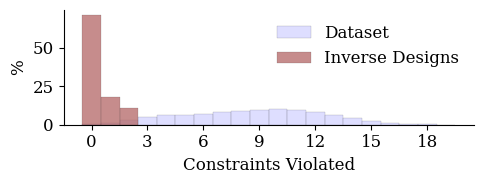

In [24]:
# Make a histogram of the number of constraints violated for the full dataset and for the feasible designs 

#Create a side by side histogram to showcase the optimized designs too values are stored in opt_hist
colors = [[.7,.4,.4], [.6,0.8,.6], [.75,.75,1]]

cons_violations_full = (con_diff > 0).sum(axis=1)
cons_violations_feas = (con_diff.loc[feas_idx] > 0).sum(axis=1)

fig, ax1 = plt.subplots(figsize=(5,2))


sns.histplot(cons_violations_full, bins=np.arange(-0.5, cons_violations_full.max()+1.5), color=colors[2], edgecolor=(0.2,0.2,0.2), linewidth = 0.1, alpha=0.5, label='Dataset',stat='percent')



sns.histplot(opt_hist, bins=np.arange(-0.5, opt_hist.max()+1.5), color=colors[0], edgecolor=(0.2,0.2,0.2), linewidth = 0.1,alpha=0.75, label='Inverse Designs', stat='percent')
ax1.set_ylabel(r'%')

plt.xlabel('Constraints Violated')

#x_ticks for each integer value of number of constraints violated
plt.xticks(np.arange(0, max(cons_violations_full.max(), opt_hist.max())+1,3))
#plt.title('Number of Constraints Violated')

#remove box around axis
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

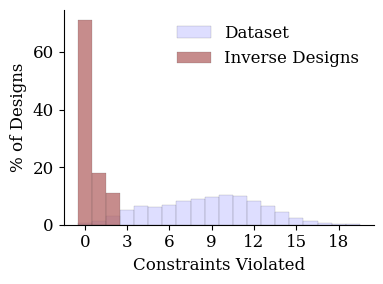

Average number of constraints violated for full dataset: 8.61
Average number of constraints violated for optimized designs: 0.40


In [21]:
# Make a histogram of the number of constraints violated for the full dataset and for the feasible designs 

#Create a side by side histogram to showcase the optimized designs too values are stored in opt_hist
colors = [[.7,.4,.4], [.6,0.8,.6], [.75,.75,1]]

cons_violations_full = (con_diff > 0).sum(axis=1)
cons_violations_feas = (con_diff.loc[feas_idx] > 0).sum(axis=1)

fig, ax1 = plt.subplots(figsize=(4,3))


sns.histplot(cons_violations_full, bins=np.arange(-0.5, cons_violations_full.max()+1.5), color=colors[2], edgecolor=(0.2,0.2,0.2), linewidth = 0.1, alpha=0.5, label='Dataset',stat='percent')



sns.histplot(opt_hist, bins=np.arange(-0.5, opt_hist.max()+1.5), color=colors[0], edgecolor=(0.2,0.2,0.2), linewidth = 0.1,alpha=0.75, label='Inverse Designs', stat='percent')
ax1.set_ylabel(r'% of Designs')

plt.xlabel('Constraints Violated')

#x_ticks for each integer value of number of constraints violated
plt.xticks(np.arange(0, max(cons_violations_full.max(), opt_hist.max())+1,3))
#plt.title('Number of Constraints Violated')

#remove box around axis
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(f"./Figures/Constraint_Violations_Histogram.png", dpi=300)
plt.show()


#print Average number of constraints violated for the full dataset and for the optimized designs
print(f'Average number of constraints violated for full dataset: {cons_violations_full.mean():.2f}')
print(f'Average number of constraints violated for optimized designs: {opt_hist.mean():.2f}')

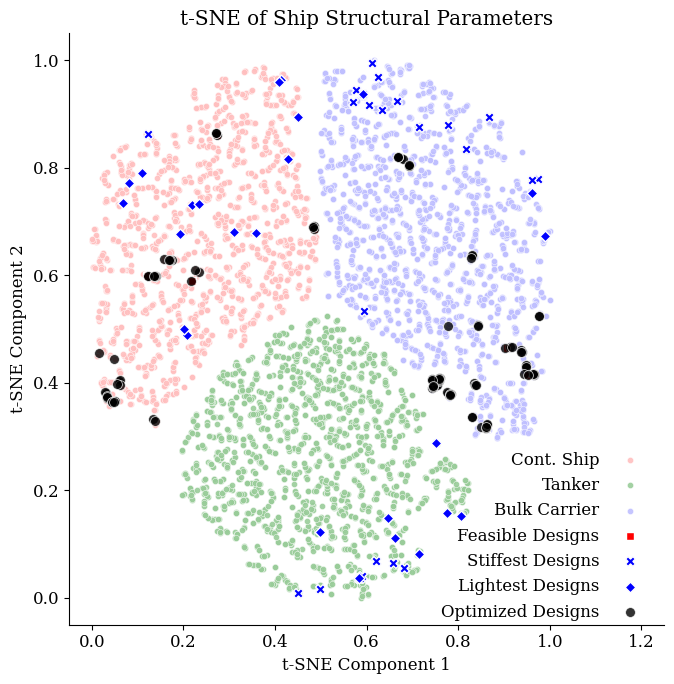

In [43]:
# Remake tsne and add the feasible designs in a different color
feas_color = [1,0,0]
colors = [[1,.75,.75], [.6,0.8,.6], [.75,.75,1]]

plt.figure(figsize=(7,7))
sns.scatterplot(x=X_tsne[x_class_idx[0],0], y=X_tsne[x_class_idx[0],1], s = 20, color=colors[0], alpha=0.9, label= 'Cont. Ship')
sns.scatterplot(x=X_tsne[x_class_idx[1],0], y=X_tsne[x_class_idx[1],1], s=20, color=colors[1], alpha=0.9, label= 'Tanker')
sns.scatterplot(x=X_tsne[x_class_idx[2],0], y=X_tsne[x_class_idx[2],1], s=20, color=colors[2], alpha=0.9, label= 'Bulk Carrier')
sns.scatterplot(x=X_tsne[feas_idx,0], y=X_tsne[feas_idx,1], linewidth = 1, marker='s', s=30, color=feas_color, alpha=1.0, label= 'Feasible Designs')
sns.scatterplot(x=X_tsne[stiffest_idx,0], y=X_tsne[stiffest_idx,1], linewidth = 1, marker='X', s=50, color=(0,0,1), alpha=1.0, label= 'Stiffest Designs')
sns.scatterplot(x=X_tsne[lightest_idx,0], y=X_tsne[lightest_idx,1], linewidth = 1, marker='D', s=30, color=(0,0,1), alpha=1.0, label= 'Lightest Designs')
sns.scatterplot(x=X_tsne[len(X_data):,0], y=X_tsne[len(X_data):,1], color='k', alpha=0.8, label='Optimized Designs', marker='o', s=50)
#remove box around x and y axis
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#Make x Lim to 1.25
plt.xlim(-0.05,1.25)

plt.title('t-SNE of Ship Structural Parameters')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(loc='center left', frameon=False,bbox_to_anchor=(0.6, 0.15), markerfirst=False)
plt.tight_layout()
plt.show()

In [44]:
# Try Merging the Constraint Data classes and the performance values with design parameters and retain tsnse 

#X_new = X_data.copy()
X_new = pd.DataFrame()
X_new['cat container'] = X_data['cat container']
X_new['cat tanker'] = X_data['cat tanker']
X_new['cat bulkcarrier'] = X_data['cat bulkcarrier']
#X_new['Unit_Steel_Weight [tons/m^3]'] = Y_data['Unit_Steel_Weight [tons/m^3]']
#X_new['Max_Bending_Moment [Nm]'] = Y_data['Max_Bending_Moment [Nm]']

# add all y
#for col in Y_data.columns:
    #X_new[col] = Y_data[col]


X_new['Constraints'] = (con_diff <= 0).all(axis=1)

# Add all different constraint violations as separate columns
for col in con_diff.columns:
    X_new[f'{col}_Violation'] = con_diff[col]

# Now let's do tsne on this new data 
tsne = TSNE(n_components=2, perplexity=1, max_iter=250)
X_tsne = tsne.fit_transform(X_new.values)





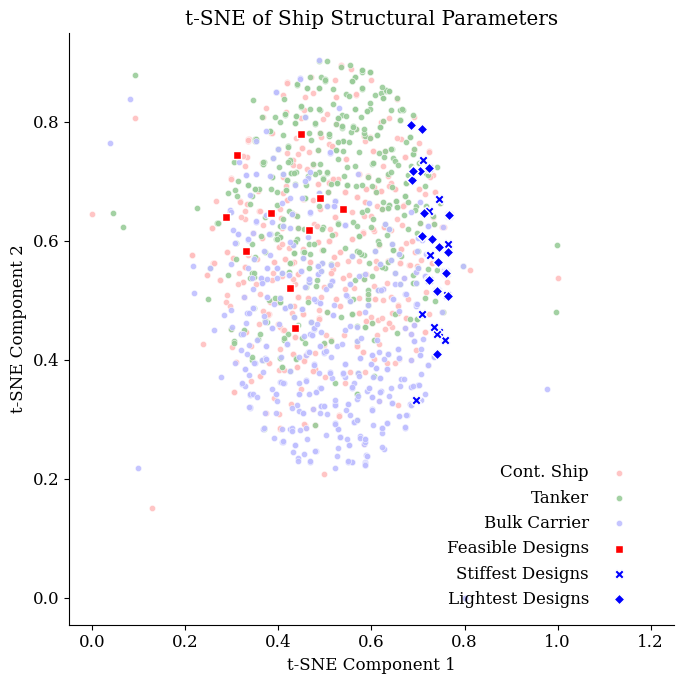

In [ ]:
num_plot = 512

plt.figure(figsize=(7,7))
#Scale TSNE components to be between 0 and 1 for better visualization
X_tsne = (X_tsne - X_tsne.min(axis=0)) / (X_tsne.max(axis=0) - X_tsne.min(axis=0))

sns.scatterplot(x=X_tsne[x_class_idx[0][0:num_plot],0], y=X_tsne[x_class_idx[0][0:num_plot],1], s = 20, color=colors[0], alpha=0.9, label= 'Cont. Ship')
sns.scatterplot(x=X_tsne[x_class_idx[1][0:num_plot],0], y=X_tsne[x_class_idx[1][0:num_plot],1], s=20, color=colors[1], alpha=0.9, label= 'Tanker')
sns.scatterplot(x=X_tsne[x_class_idx[2][0:num_plot],0], y=X_tsne[x_class_idx[2][0:num_plot],1], s=20, color=colors[2], alpha=0.9, label= 'Bulk Carrier')
sns.scatterplot(x=X_tsne[feas_idx,0], y=X_tsne[feas_idx,1], linewidth = 1, marker='s', s=30, color=feas_color, alpha=1.0, label= 'Feasible Designs')
sns.scatterplot(x=X_tsne[stiffest_idx,0], y=X_tsne[stiffest_idx,1], linewidth = 1, marker='X', s=50, color=(0,0,1), alpha=1.0, label= 'Stiffest Designs')
sns.scatterplot(x=X_tsne[lightest_idx,0], y=X_tsne[lightest_idx,1], linewidth = 1, marker='D', s=30, color=(0,0,1), alpha=1.0, label= 'Lightest Designs')


#remove box around x and y axis
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#Make x Lim to 1.25
plt.xlim(-0.05,1.25)

plt.title('t-SNE of Ship Structural Parameters')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(loc='center left', frameon=False,bbox_to_anchor=(0.6, 0.15), markerfirst=False)
plt.tight_layout()
plt.show()


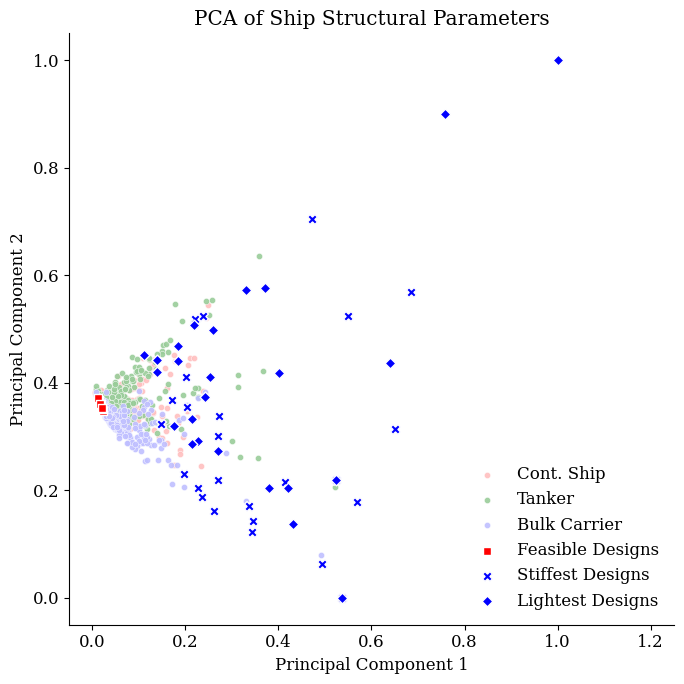

In [46]:
# Let's retry PCA with the new data that includes the performance values and constraint satisfaction as features
num_plot = 512

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_new.values)

X_pca = (X_pca - X_pca.min(axis=0)) / (X_pca.max(axis=0) - X_pca.min(axis=0))

plt.figure(figsize=(7,7))
sns.scatterplot(x=X_pca[x_class_idx[0][0:num_plot],0], y=X_pca[x_class_idx[0][0:num_plot],1], s = 20, color=colors[0], alpha=0.9, label= 'Cont. Ship')
sns.scatterplot(x=X_pca[x_class_idx[1][0:num_plot],0], y=X_pca[x_class_idx[1][0:num_plot],1], s=20, color=colors[1], alpha=0.9, label= 'Tanker')
sns.scatterplot(x=X_pca[x_class_idx[2][0:num_plot],0], y=X_pca[x_class_idx[2][0:num_plot],1], s=20, color=colors[2], alpha=0.9, label= 'Bulk Carrier')
sns.scatterplot(x=X_pca[feas_idx,0], y=X_pca[feas_idx,1], linewidth = 1, marker='s', s=30, color=feas_color, alpha=1.0, label= 'Feasible Designs')
sns.scatterplot(x=X_pca[stiffest_idx,0], y=X_pca[stiffest_idx,1], linewidth = 1, marker='X', s=50, color=(0,0,1), alpha=1.0, label= 'Stiffest Designs')
sns.scatterplot(x=X_pca[lightest_idx,0], y=X_pca[lightest_idx,1], linewidth = 1, marker='D', s=30, color=(0,0,1), alpha=1.0, label= 'Lightest Designs') 


#remove box around x and y axis
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#Make x Lim to 1.25
plt.xlim(-0.05,1.25)
plt.title('PCA of Ship Structural Parameters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()